In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_style("darkgrid")

# Preprocessing

In [2]:
parametrized_data = pd.read_csv('torgo_nopreemph_hamming256_lengths_prompts_categories.csv', index_col=0)

In [3]:
parametrized_data.head()

,path,prompt,prompt_category,length_samples,length_seconds,label,ASC,ASC_VAR,ASS,ASS_VAR,...,MFCC11,MFCC12,MFCC13,MFCC14,MFCC15,MFCC16,MFCC17,MFCC18,MFCC19,MFCC20
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,E:\STUDIA\semestr 8\WSI\Projekt\Data\TORGO\F_C...,[say 'Ah-P-Eee' repeatedly],non_word,148800,9.30,0,0.184410,2.844485,1.273322,0.220922,...,-7.778514,-10.919192,-4.185398,1.887481,-11.467344,-2.290919,-7.579661,-0.282507,-1.545831,-4.981239
1,E:\STUDIA\semestr 8\WSI\Projekt\Data\TORGO\F_C...,[say 'Ah-P-Eee' repeatedly],non_word,117600,7.35,0,0.277446,1.609560,1.213796,0.239385,...,-7.755306,-11.975713,-5.653173,2.960525,-11.595507,-4.439202,-7.003992,1.081950,-1.133004,-4.651984
2,E:\STUDIA\semestr 8\WSI\Projekt\Data\TORGO\F_C...,[relax your mouth in its normal position],non_word,84000,5.25,0,1.302371,3.798506,1.562590,0.341607,...,-0.256529,3.685362,-6.653706,3.827842,-6.690595,-7.278024,-8.413125,8.260308,-3.556110,-7.026837
3,E:\STUDIA\semestr 8\WSI\Projekt\Data\TORGO\F_C...,[say 'Eee-P-Ah' repeatedly],non_word,74400,4.65,0,-1.541566,1.811958,1.361026,0.282031,...,-6.343857,-11.931686,-3.549286,3.298603,-12.613104,-5.415185,-8.174975,-1.634353,-1.733258,-5.088470
4,E:\STUDIA\semestr 8\WSI\Projekt\Data\TORGO\F_C...,dug,short_word,36000,2.25,0,1.654178,1.164576,1.245388,0.075248,...,-1.878599,1.480944,-4.954466,2.208425,-8.516620,-7.300495,-9.873207,5.013566,-2.680927,-5.904635


In [4]:
parametrized_data.describe()

,length_samples,length_seconds,label,ASC,ASC_VAR,ASS,ASS_VAR,ASF1,ASF2,ASF3,...,MFCC11,MFCC12,MFCC13,MFCC14,MFCC15,MFCC16,MFCC17,MFCC18,MFCC19,MFCC20
count,1.762700e+04,17627.000000,17627.000000,17627.000000,17627.000000,17627.000000,17627.000000,17627.000000,17627.000000,17627.000000,...,17600.000000,17600.000000,17600.000000,17600.000000,17600.000000,17600.000000,17600.000000,17600.000000,17594.000000,17594.000000
mean,4.959809e+04,3.099881,0.350145,-0.782094,1.284389,1.396764,0.223236,0.029333,0.033585,0.036858,...,-6.978791,1.693950,-4.215405,0.324436,-9.267599,-3.032001,-6.256118,3.355221,-5.069581,-4.308916
std,4.696923e+04,2.935577,0.477029,1.885629,0.782782,0.194592,0.123602,0.059822,0.066962,0.074063,...,3.469089,3.747620,3.114617,2.498502,3.168573,2.657252,2.547337,2.227849,2.334446,2.276506
min,1.340000e+02,0.008375,0.000000,-4.550933,0.027110,0.397898,0.003318,0.000080,0.000252,0.000552,...,-25.236315,-30.496828,-18.601119,-18.729565,-29.843425,-18.544276,-21.012648,-10.909122,-17.987459,-15.226478
25%,2.920000e+04,1.825000,0.000000,-2.683019,0.711463,1.280318,0.136205,0.005770,0.008901,0.010240,...,-9.451721,-0.714341,-6.516663,-1.265476,-11.477398,-4.823552,-7.967061,1.934680,-6.695117,-5.993451
50%,4.080000e+04,2.550000,0.000000,-0.794039,1.154022,1.389013,0.194263,0.018291,0.019274,0.019590,...,-7.035748,1.690285,-4.324599,0.497200,-9.448567,-2.937308,-6.500984,3.382575,-4.930001,-4.354092
75%,5.588000e+04,3.492500,1.000000,1.161300,1.729409,1.495685,0.278617,0.026789,0.027342,0.027427,...,-4.500546,4.412338,-2.149349,2.067690,-7.232395,-1.050280,-4.797347,4.823446,-3.398264,-2.651237
max,3.101258e+06,193.828625,1.000000,2.161076,7.578349,2.778215,1.136022,0.617158,0.645355,0.669565,...,9.253432,12.522576,15.590447,13.549545,12.995606,28.001638,26.836683,25.132935,17.776215,20.843233


### Dropping 'path' column

In [4]:
file_names = parametrized_data['path']
file_names = file_names.str.split('\\').str[-1]
parametrized_data = parametrized_data.drop('path', axis=1)
parametrized_data = parametrized_data.drop('length_samples', axis=1)
parametrized_data = parametrized_data.drop('prompt', axis=1)
parametrized_data = parametrized_data.drop('length_seconds', axis=1)

### Displaying number of NaN values

In [5]:
print("Number of NaN values:")
print(parametrized_data.isna().sum().sum())

Number of NaN values:
904


In [45]:
print("Number of NaN values:")
print(parametrized_data.isnull().sum().sum())

Number of NaN values:
0


In [6]:
print("Number of NaN values:")
print(parametrized_data.loc[:, parametrized_data.isna().any()])

Number of NaN values:
                 LAT      ASP7      ASP8      ASP9     ASP10     ASP11  \
Unnamed: 0                                                               
0           0.484015  0.207756  0.105959 -0.007509  0.006592  0.121457   
1           0.042969  0.149551 -0.180321 -0.047139  0.006995  0.110820   
2          -2.096910  0.040245  0.012333 -0.023296 -0.026949 -0.008912   
3          -0.028724  0.116275  0.108633  0.149639  0.126676  0.036103   
4          -0.036212  0.022620 -0.006500 -0.066760 -0.036428  0.026588   
...              ...       ...       ...       ...       ...       ...   
17622       0.151063 -0.141389  0.114016  0.067129  0.014543  0.059755   
17623       0.221153 -0.232559  0.175838 -0.081666 -0.041109 -0.041161   
17624       0.148603  0.027870 -0.011928 -0.015190 -0.045292 -0.020661   
17625       0.020361  0.030764 -0.024325  0.090252  0.047648 -0.007858   
17626       0.030195  1.172344 -0.019019  0.008538 -0.316039 -0.153770   

               

### Replace NaN values with 0

In [6]:
parametrized_data = parametrized_data.fillna(0)
print("Number of NaN values:")
print(parametrized_data.isna().sum().sum())

Number of NaN values:
0


In [8]:
parametrized_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17627 entries, 0 to 17626
Columns: 129 entries, prompt_category to MFCC20
dtypes: float64(127), int64(1), object(1)
memory usage: 17.5+ MB


In [9]:
parametrized_data.head()

,prompt_category,label,ASC,ASC_VAR,ASS,ASS_VAR,ASF1,ASF2,ASF3,ASF4,...,MFCC11,MFCC12,MFCC13,MFCC14,MFCC15,MFCC16,MFCC17,MFCC18,MFCC19,MFCC20
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,non_word,0,0.184410,2.844485,1.273322,0.220922,0.015476,0.015857,0.016008,0.016315,...,-7.778514,-10.919192,-4.185398,1.887481,-11.467344,-2.290919,-7.579661,-0.282507,-1.545831,-4.981239
1,non_word,0,0.277446,1.609560,1.213796,0.239385,0.010860,0.010890,0.011123,0.011627,...,-7.755306,-11.975713,-5.653173,2.960525,-11.595507,-4.439202,-7.003992,1.081950,-1.133004,-4.651984
2,non_word,0,1.302371,3.798506,1.562590,0.341607,0.029975,0.029691,0.029485,0.029375,...,-0.256529,3.685362,-6.653706,3.827842,-6.690595,-7.278024,-8.413125,8.260308,-3.556110,-7.026837
3,non_word,0,-1.541566,1.811958,1.361026,0.282031,0.008565,0.011450,0.013251,0.014728,...,-6.343857,-11.931686,-3.549286,3.298603,-12.613104,-5.415185,-8.174975,-1.634353,-1.733258,-5.088470
4,short_word,0,1.654178,1.164576,1.245388,0.075248,0.023994,0.023977,0.024223,0.024578,...,-1.878599,1.480944,-4.954466,2.208425,-8.516620,-7.300495,-9.873207,5.013566,-2.680927,-5.904635


### Splitting data

In [7]:
parametrized_data_2 = parametrized_data.copy()

group1_categories = ['non_word', 'short_word']
group2_categories = ['restricted_sentence', 'unrestricted_sentence']

group1_data = parametrized_data_2[parametrized_data_2['prompt_category'].isin(group2_categories)]
y = parametrized_data_2['label']
X = parametrized_data_2.drop('label',axis=1).copy()

In [8]:
X = X.drop('prompt_category', axis=1)

### Scaling

In [9]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler,  MaxAbsScaler, PowerTransformer,QuantileTransformer
scaler = QuantileTransformer(n_quantiles=100, output_distribution='normal')
X = scaler.fit_transform(X)
data_2 = pd.DataFrame(X, columns=parametrized_data.columns[2:])

In [10]:
data_2.head()

,ASC,ASC_VAR,ASS,ASS_VAR,ASF1,ASF2,ASF3,ASF4,ASF5,ASF6,...,MFCC11,MFCC12,MFCC13,MFCC14,MFCC15,MFCC16,MFCC17,MFCC18,MFCC19,MFCC20
0,0.152611,1.848828,-0.701565,0.241935,-0.125683,-0.162346,-0.222551,-0.333326,-0.365176,-0.612904,...,-0.205920,-2.377677,0.057481,0.611209,-0.667248,0.230121,-0.489591,-1.656353,1.630846,-0.245639
1,0.179283,0.528851,-1.044717,0.400280,-0.271725,-0.503630,-0.590448,-0.726477,-0.798233,-1.111323,...,-0.199478,-2.398066,-0.371965,1.129638,-0.716018,-0.538542,-0.232150,-1.045228,1.838854,-0.110036
2,0.792015,2.336029,1.085256,1.053140,1.093695,0.981578,0.942041,0.910103,0.883606,0.800275,...,1.964153,0.515180,-0.710187,1.573118,0.835564,-1.569051,-0.894403,2.208673,0.594112,-1.174023
3,-0.096263,0.772304,-0.167314,0.697116,-0.375030,-0.461690,-0.434796,-0.445198,-0.342599,-0.513390,...,0.179810,-2.397196,0.256800,1.305266,-1.097990,-0.882220,-0.783937,-2.175360,1.532925,-0.290419
4,1.443468,-0.004464,-0.861235,-1.845134,0.334825,0.284668,0.293070,0.303065,0.291023,0.169242,...,1.477172,-0.054092,-0.166118,0.768727,0.292371,-1.577787,-1.622524,0.756186,1.029283,-0.628219


## Plotting original data

In [10]:
n_features_per_plot = len(data_2.columns) // 8
indexes = []
for i in range(8):
    start_idx = i * n_features_per_plot
    end_idx = start_idx + n_features_per_plot
    indexes.append((start_idx,end_idx))
    

### Violing plots

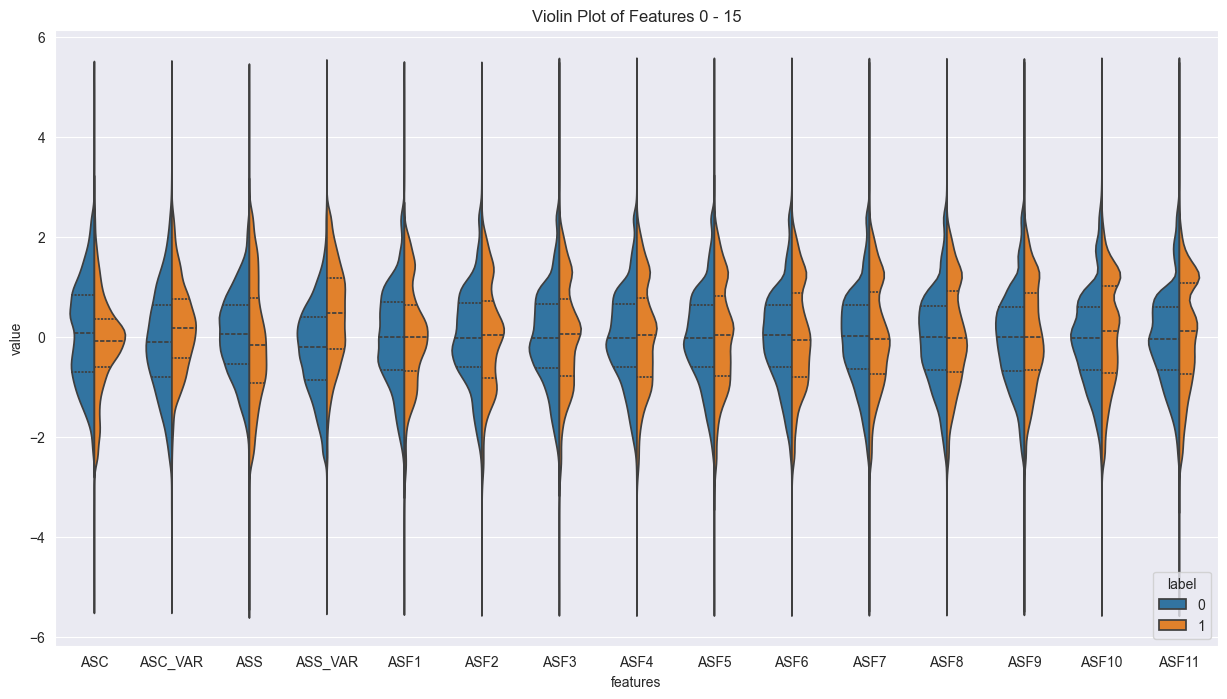

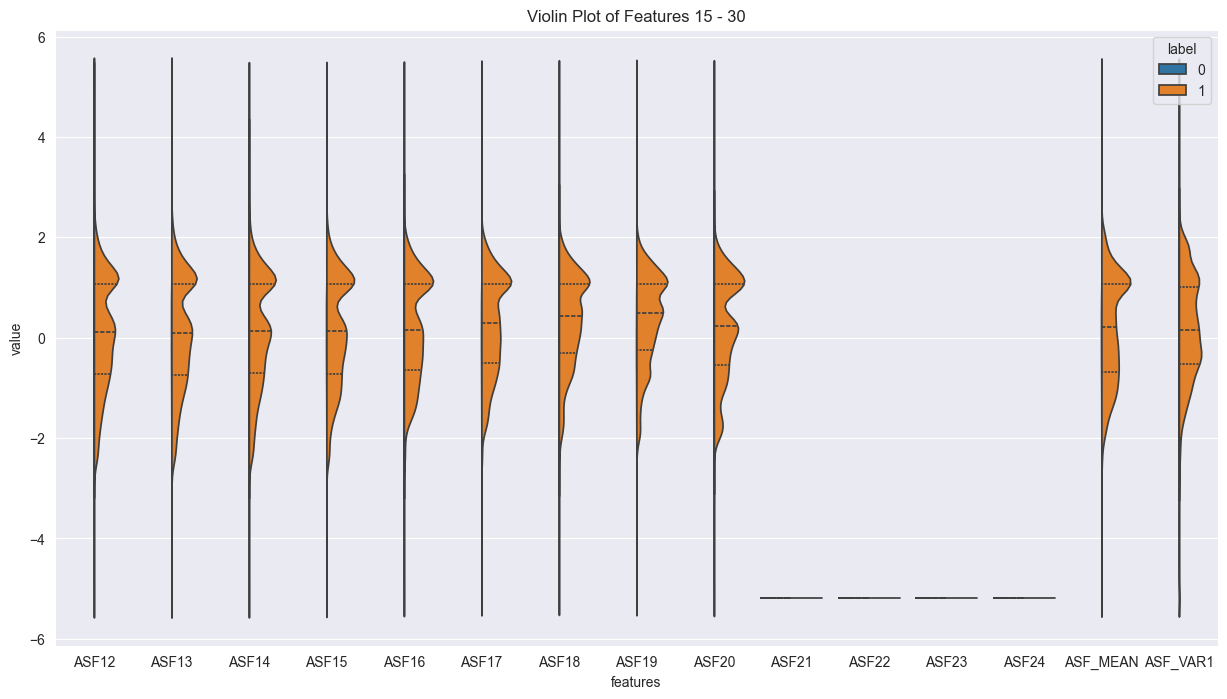

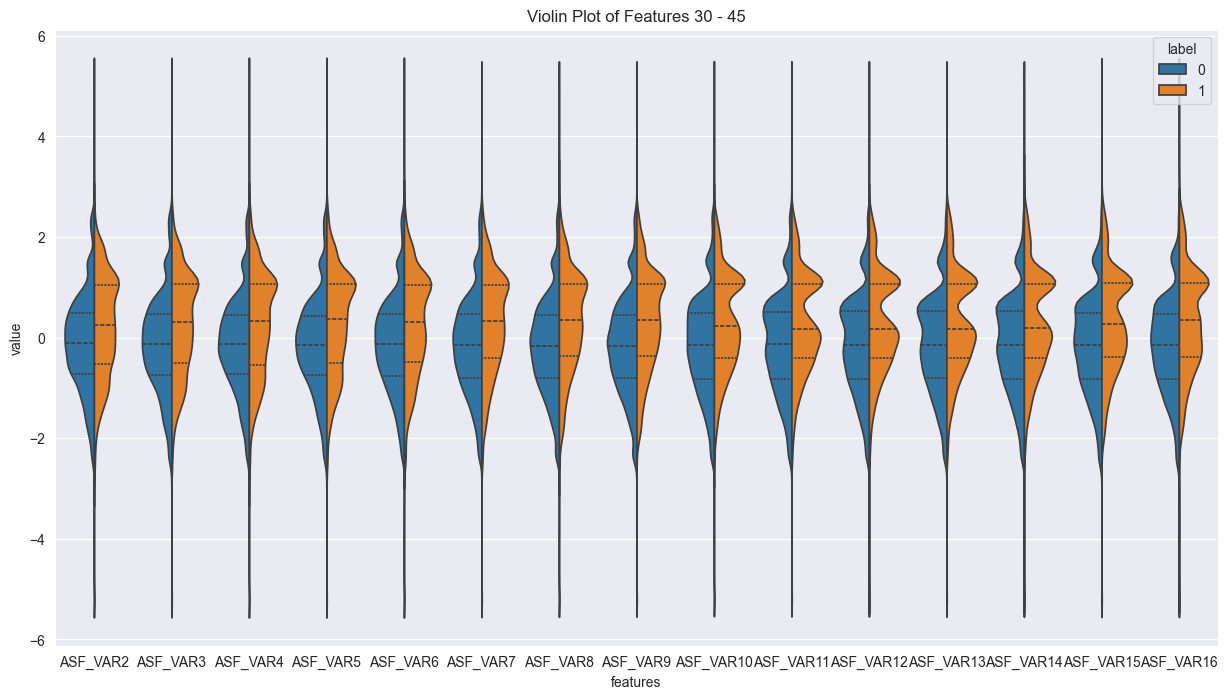

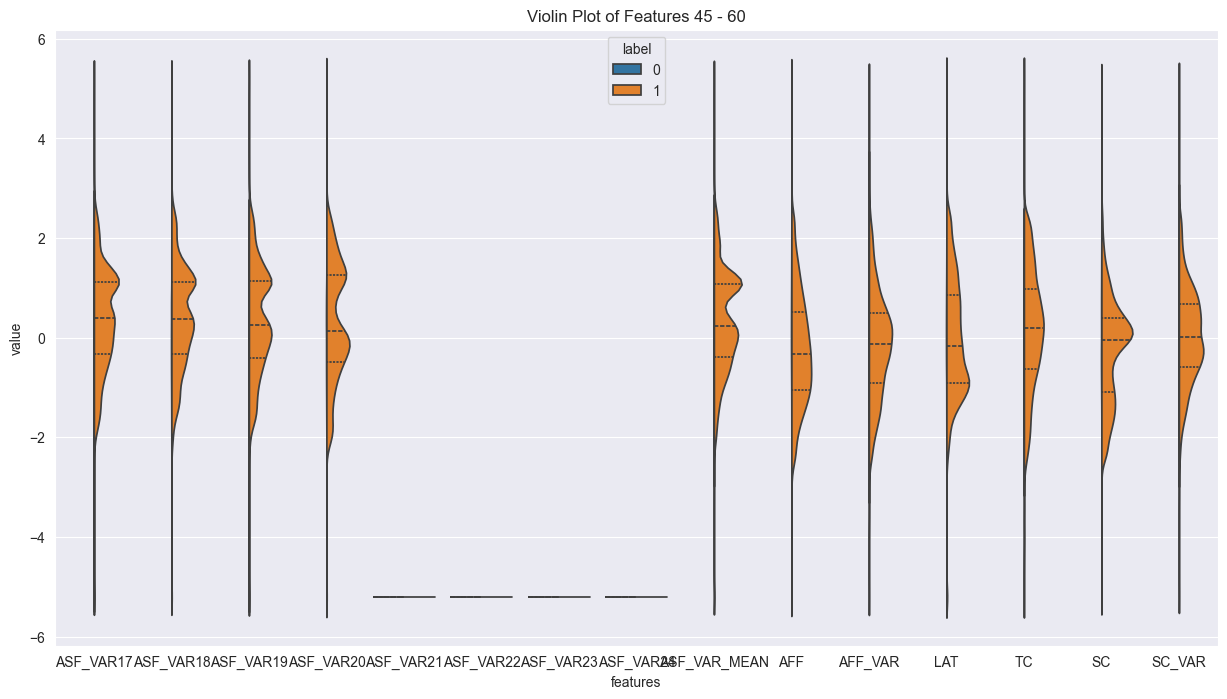

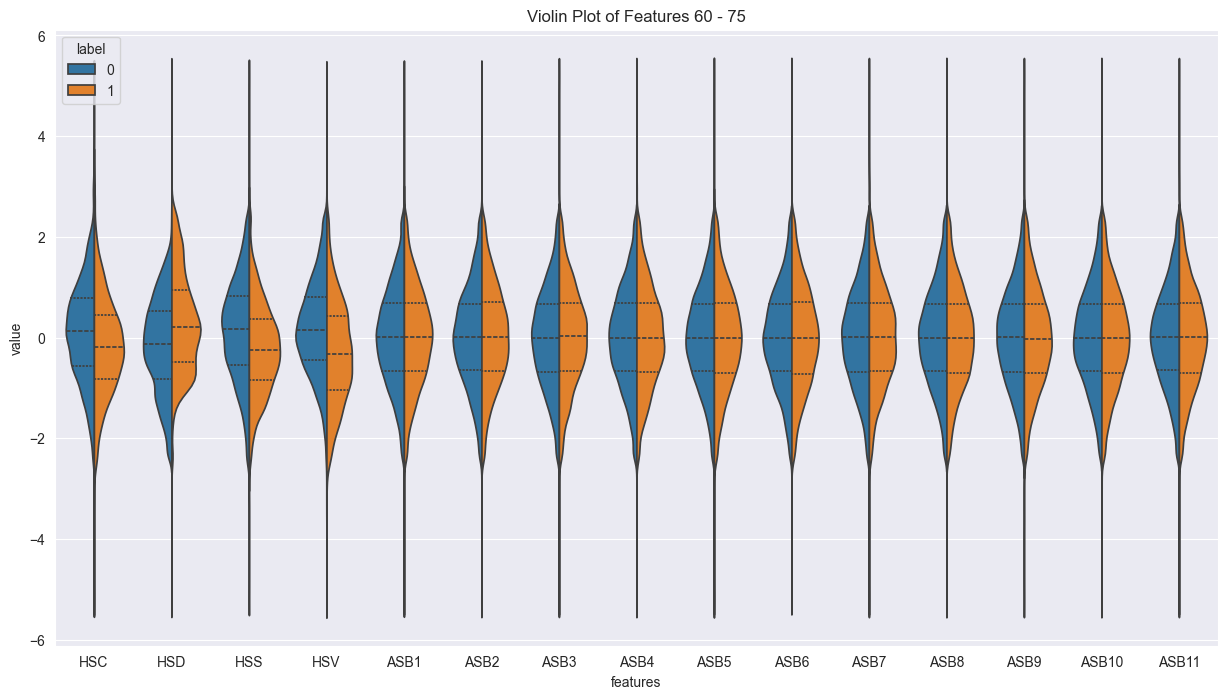

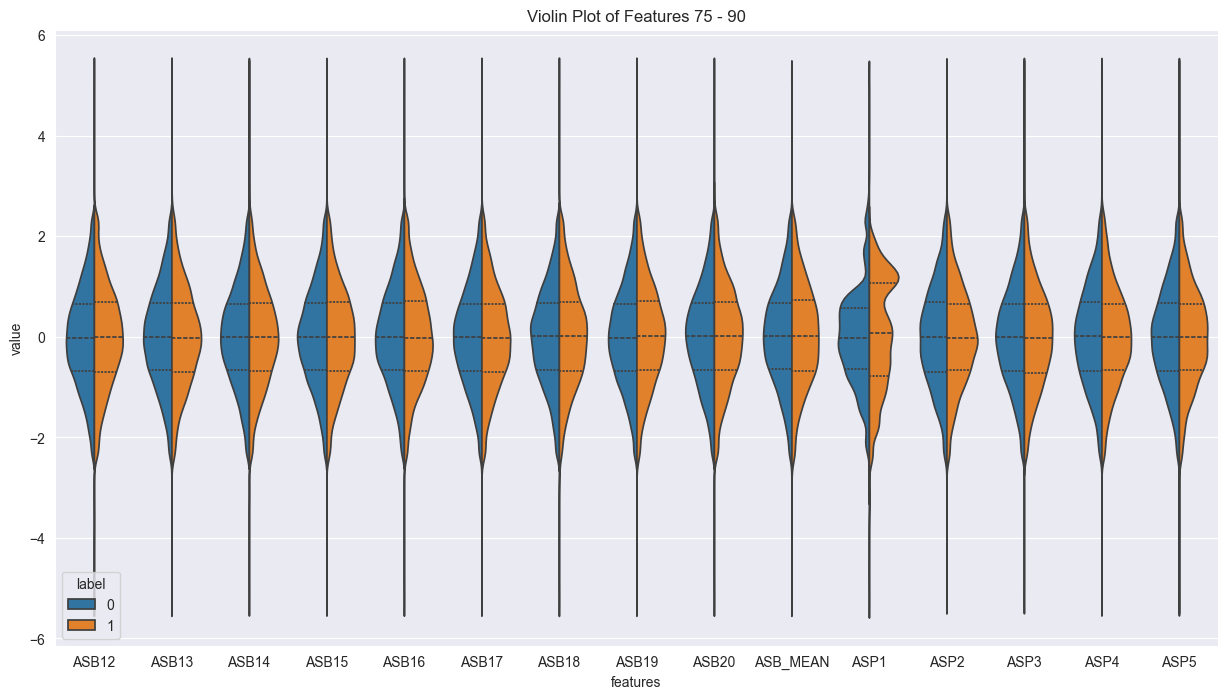

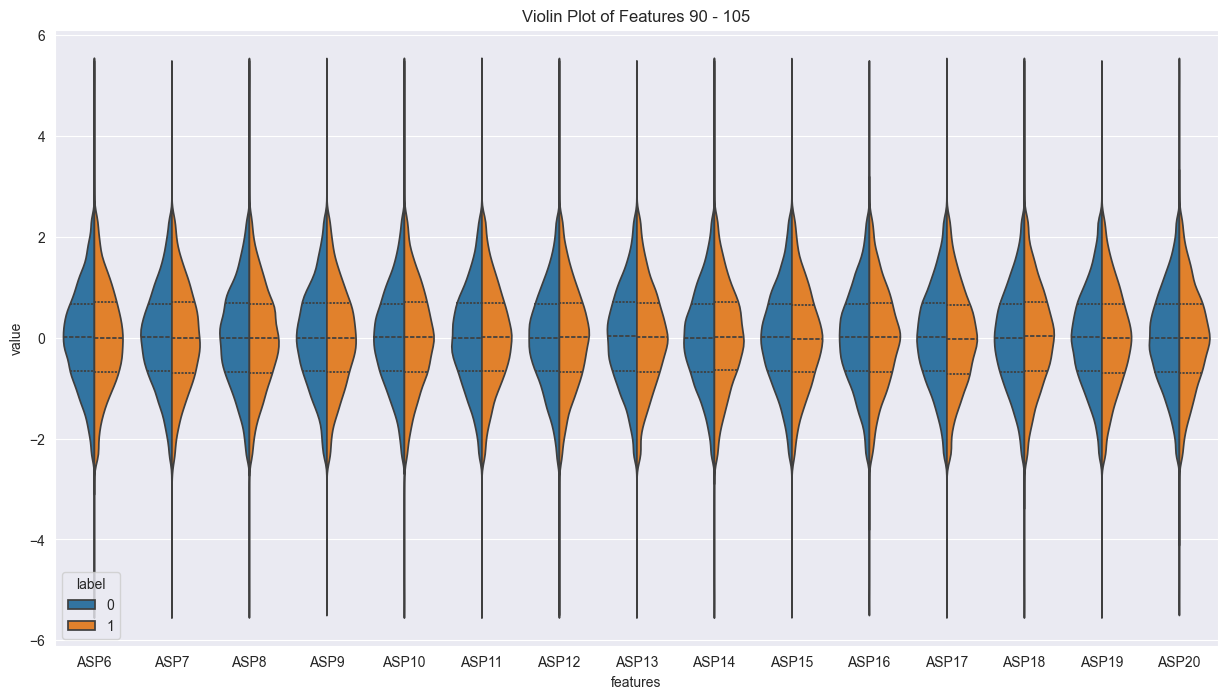

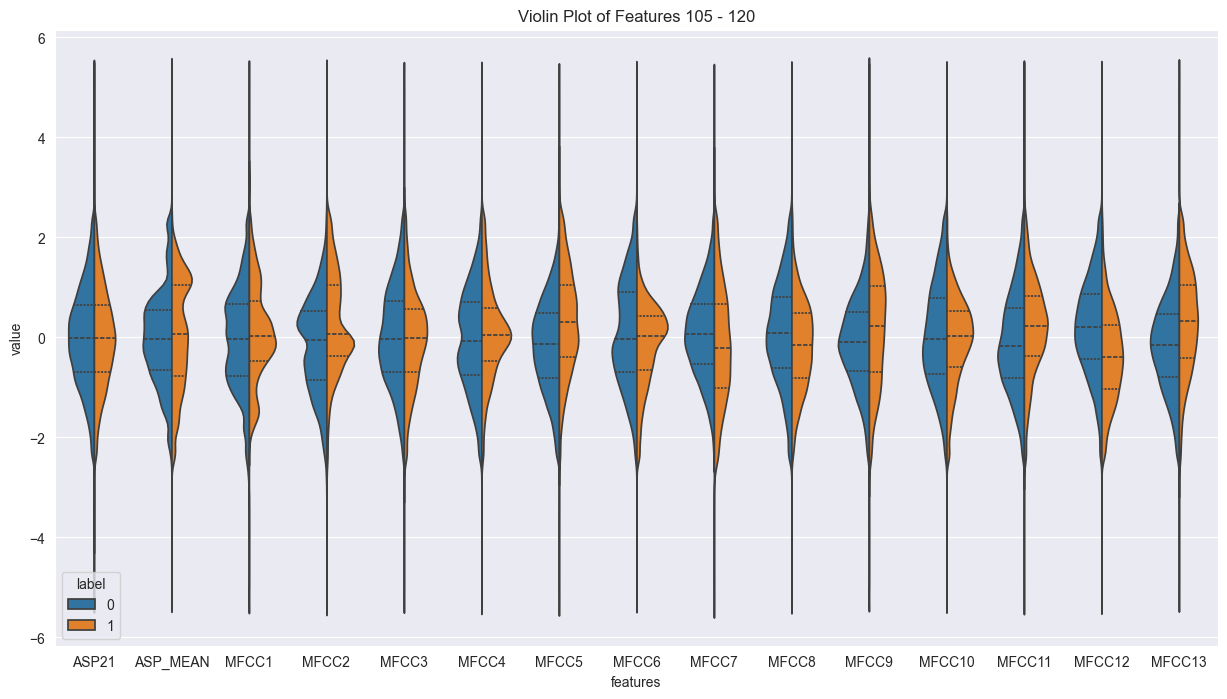

In [11]:

for i in range(8):
    plt.figure(figsize=(15, 8))
    data_ = pd.concat([y, data_2.iloc[:, indexes[i][0]:indexes[i][1]]], axis=1)
    data_ = pd.melt(data_, id_vars="label", var_name="features", value_name="value")
    sns.violinplot(x="features", y="value", hue="label", data=data_,
                   split=True, inner="quart")
    plt.title(f"Violin Plot of Features {indexes[i][0]} - {indexes[i][1]}")


Outliers in 60 - 128

### Box plots

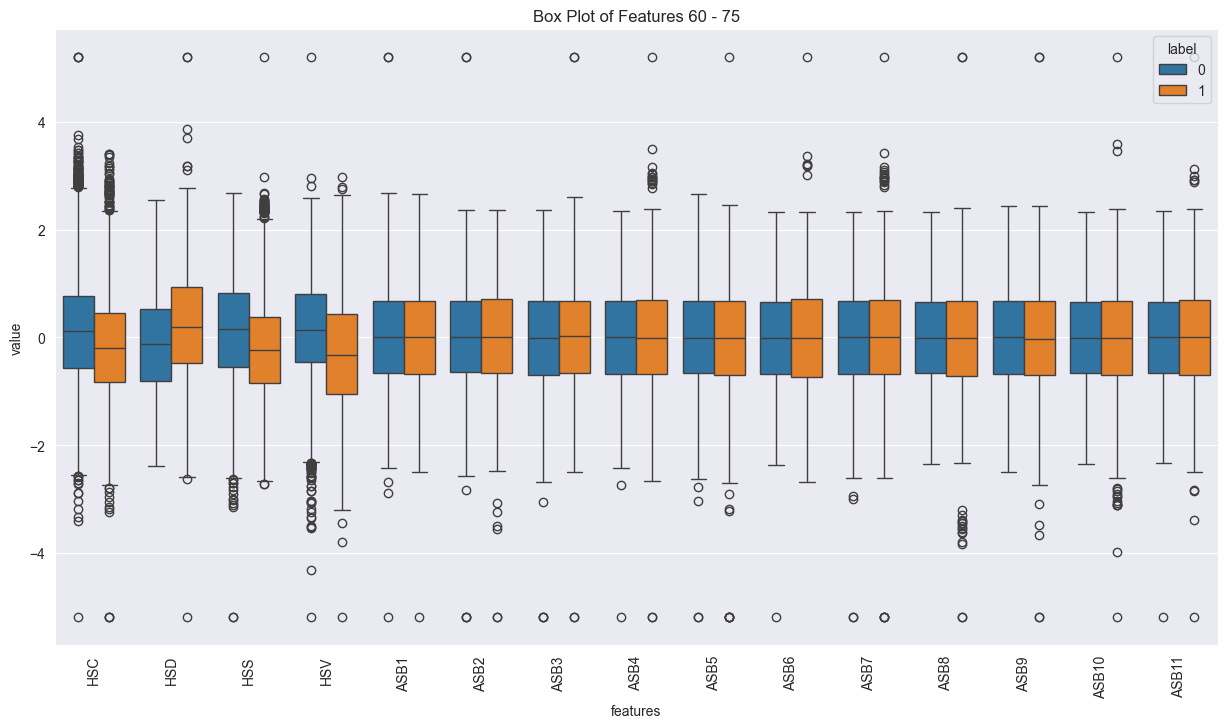

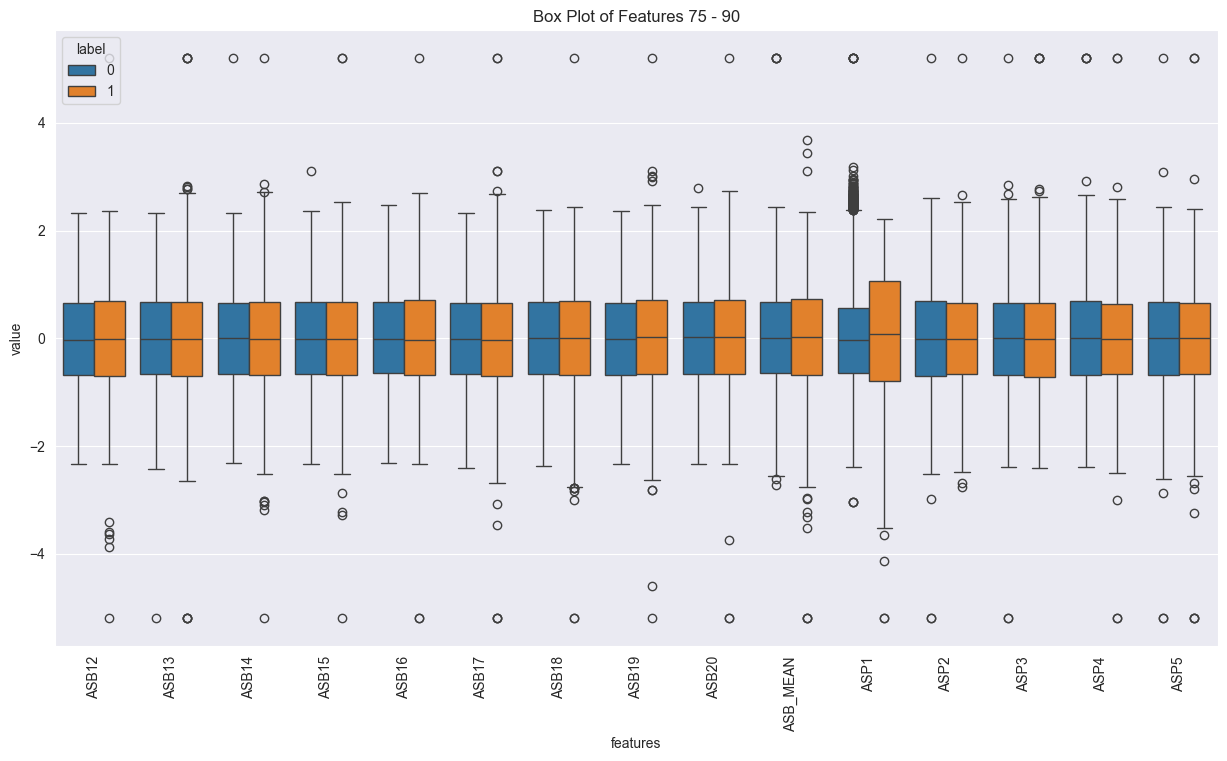

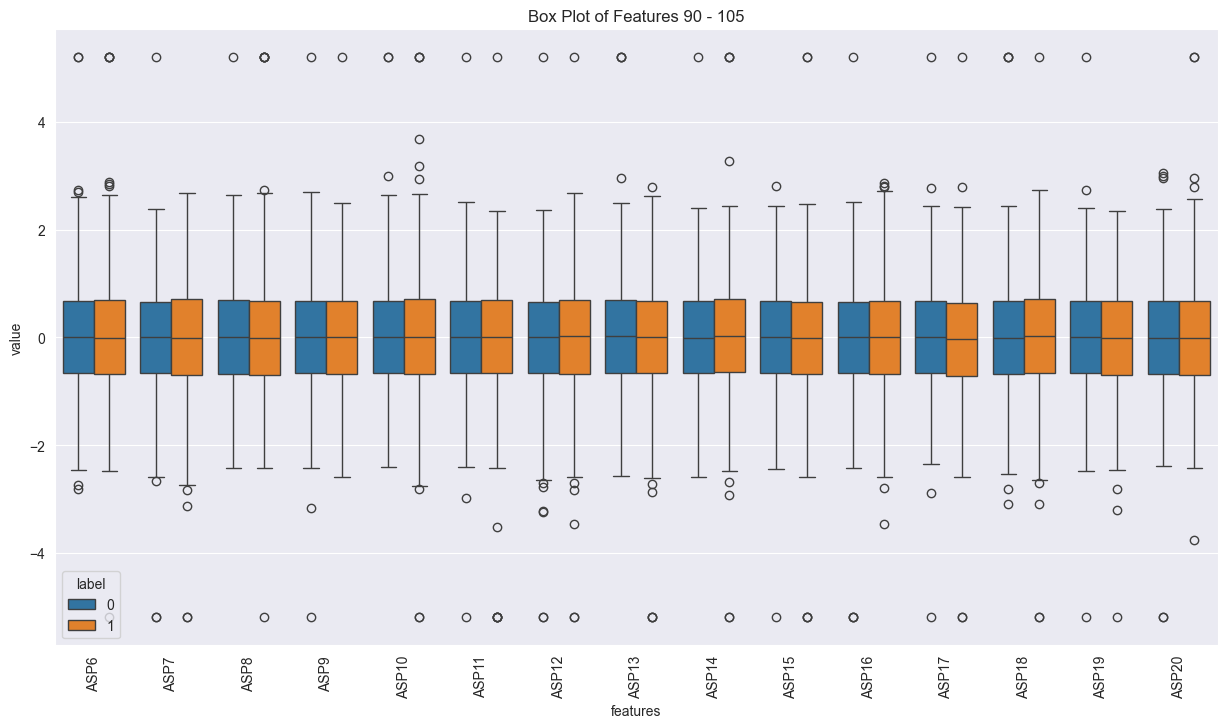

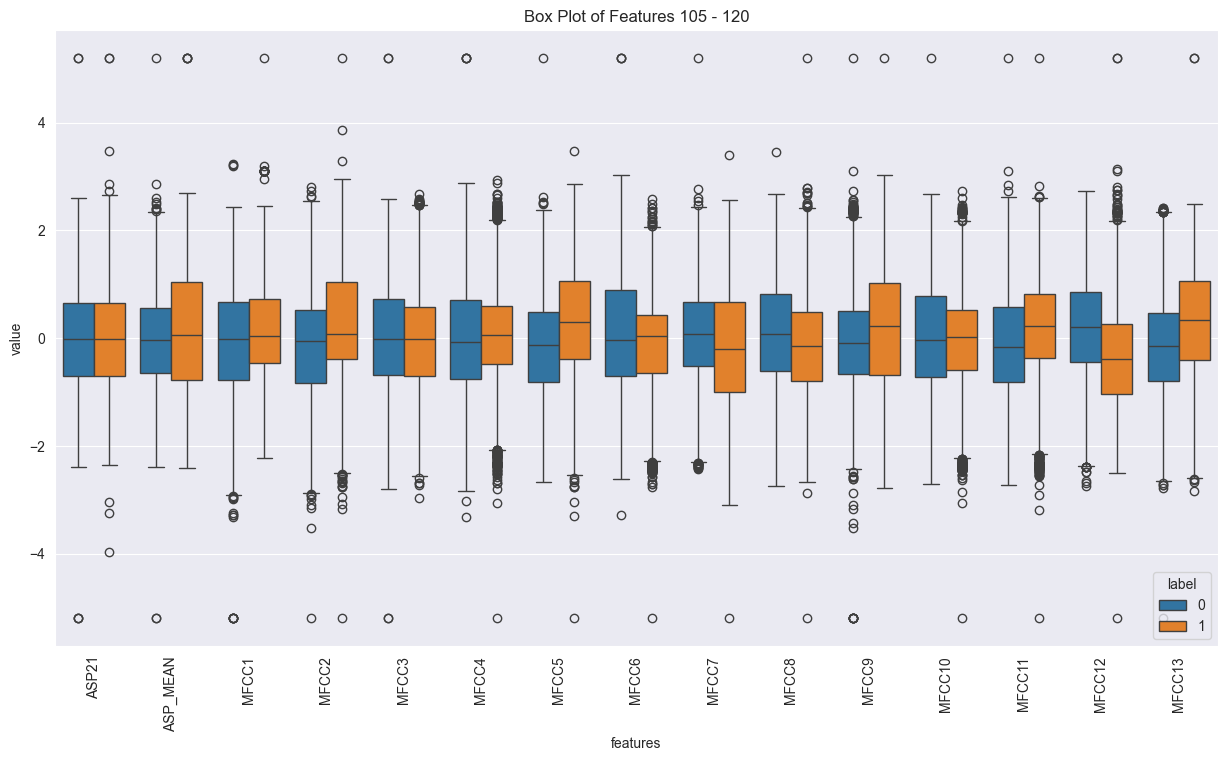

In [12]:
for i in range(4,8):
    plt.figure(figsize=(15, 8))
    data_ = pd.concat([y, data_2.iloc[:, indexes[i][0]:indexes[i][1]]], axis=1)
    data_ = pd.melt(data_, id_vars="label", var_name="features", value_name="value")
    sns.boxplot(x="features", y="value", hue="label", data=data_)
    plt.xticks(rotation=90)
    plt.title(f"Box Plot of Features {indexes[i][0]} - {indexes[i][1]}")

### Strip plots

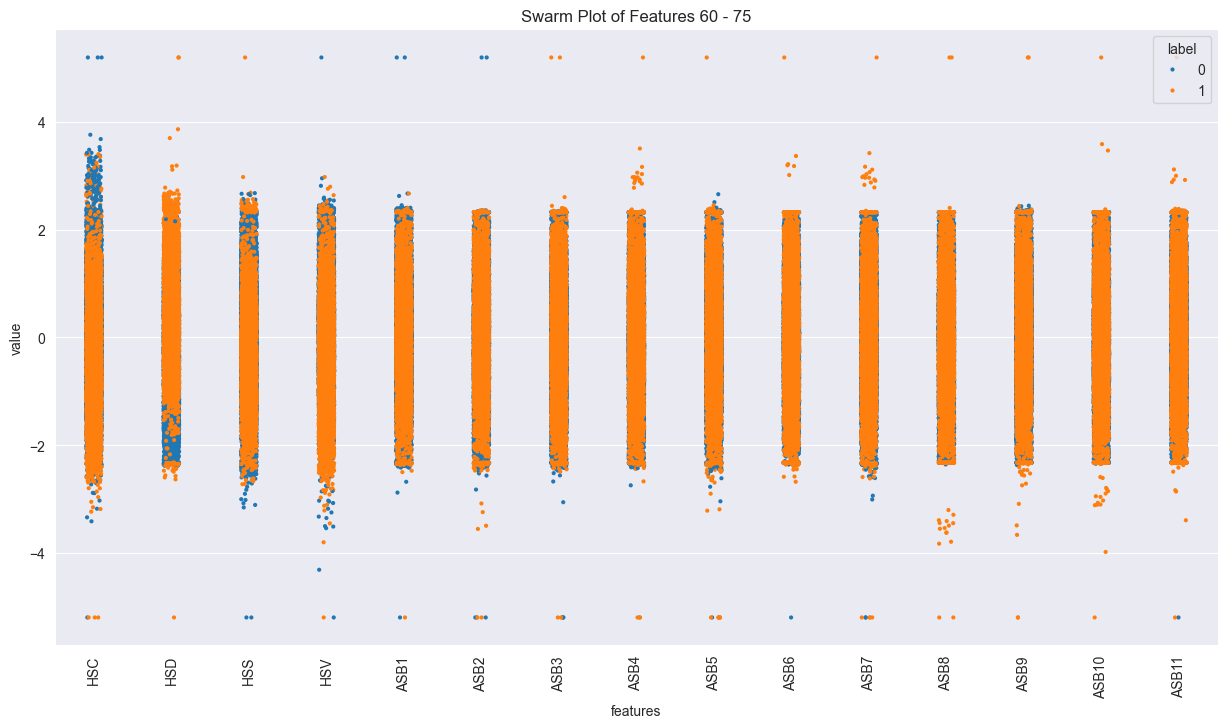

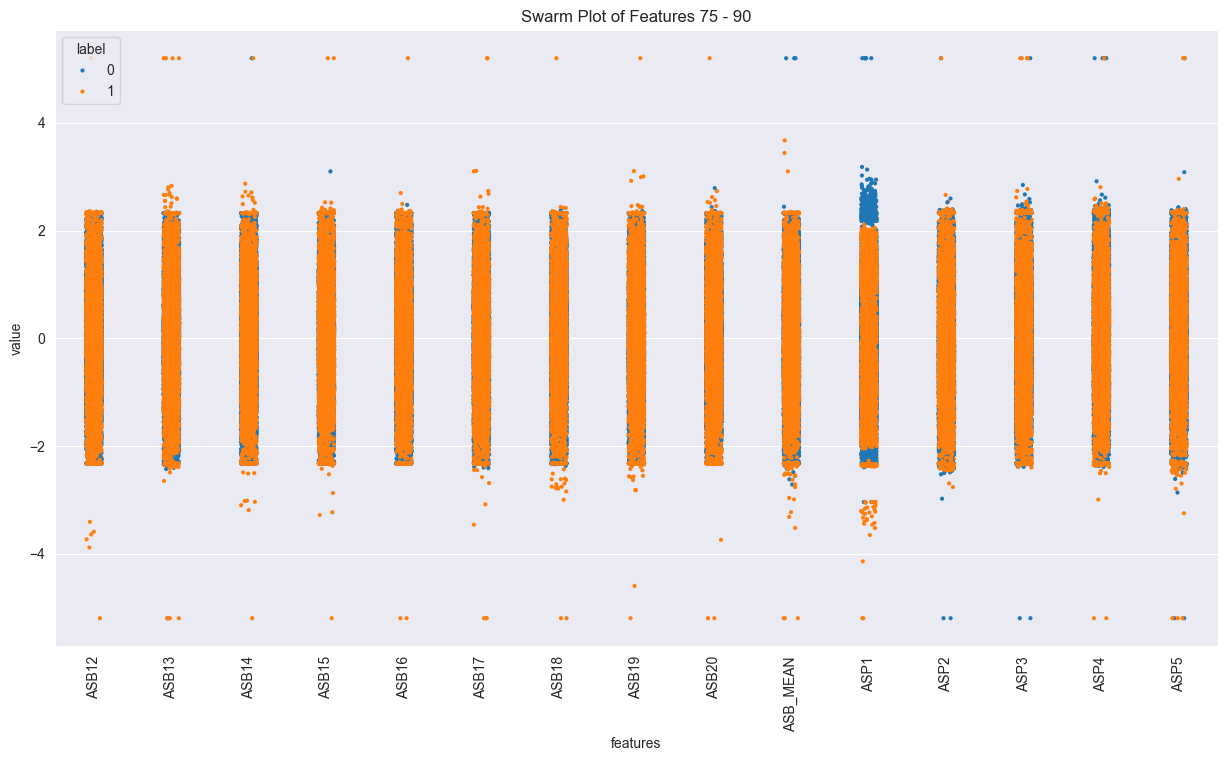

c:\Users\poreb\anaconda3\envs\mmi_lab\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


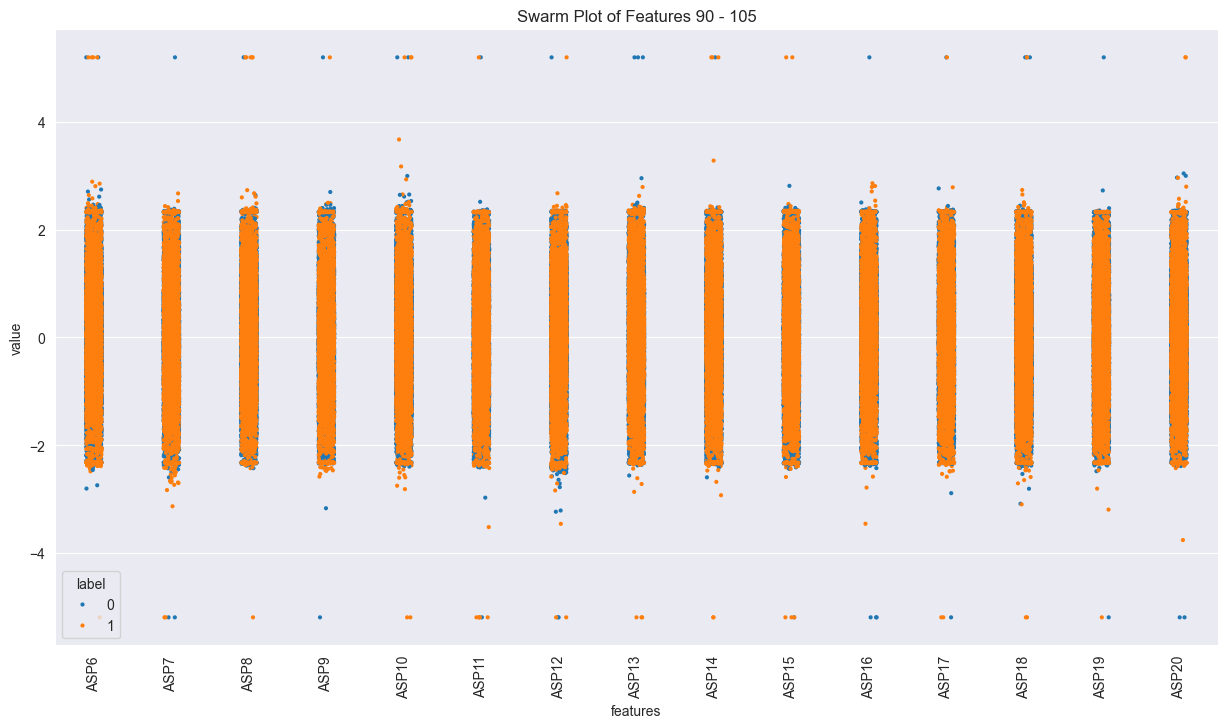

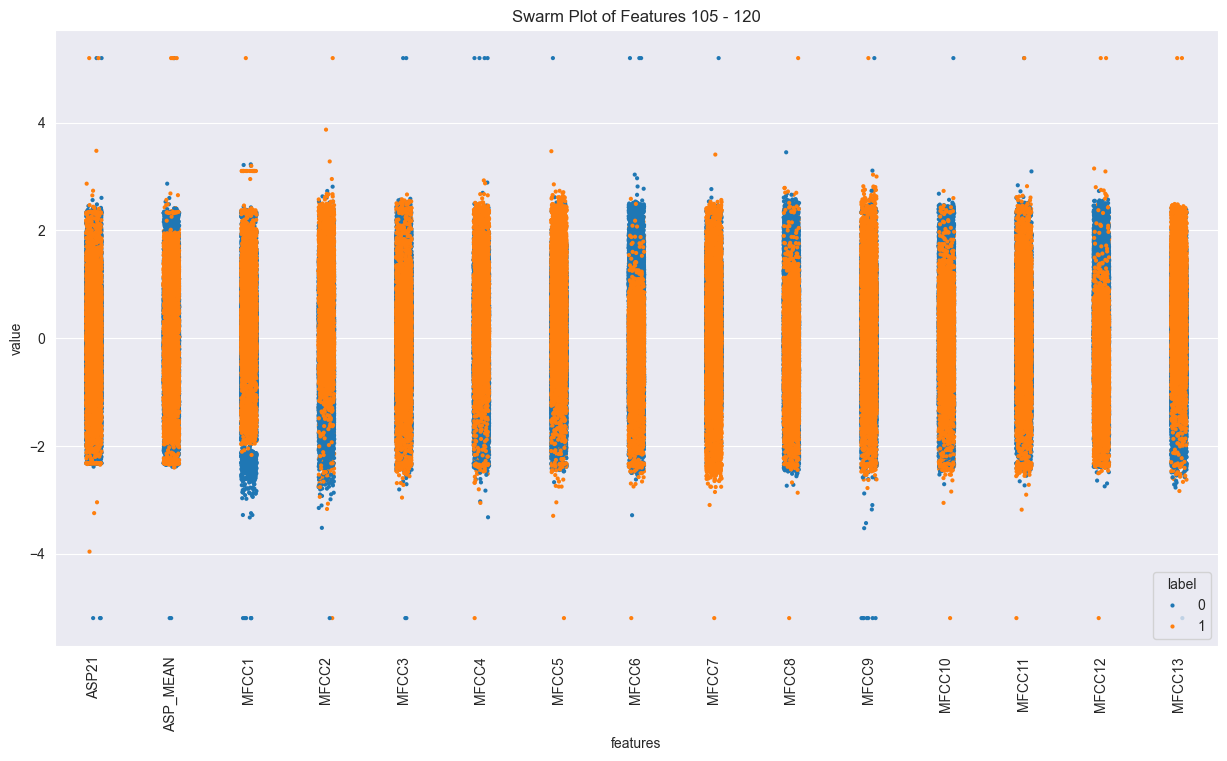

In [13]:
for i in range(4,8):
    plt.figure(figsize=(15, 8))
    data_ = pd.concat([y, data_2.iloc[:, indexes[i][0]:indexes[i][1]]], axis=1)
    data_ = pd.melt(data_, id_vars="label", var_name="features", value_name="value")
    sns.stripplot(x="features", y="value", hue="label", data=data_, size=3)
    plt.xticks(rotation=90)
    plt.title(f"Swarm Plot of Features {indexes[i][0]} - {indexes[i][1]}")

### Swarm plot of random 2000 Samples

c:\Users\poreb\anaconda3\envs\mmi_lab\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 86.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\poreb\anaconda3\envs\mmi_lab\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 84.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\poreb\anaconda3\envs\mmi_lab\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 82.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\poreb\anaconda3\envs\mmi_lab\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 83.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\poreb\anaconda3\envs\mmi_lab\Lib\site-packa

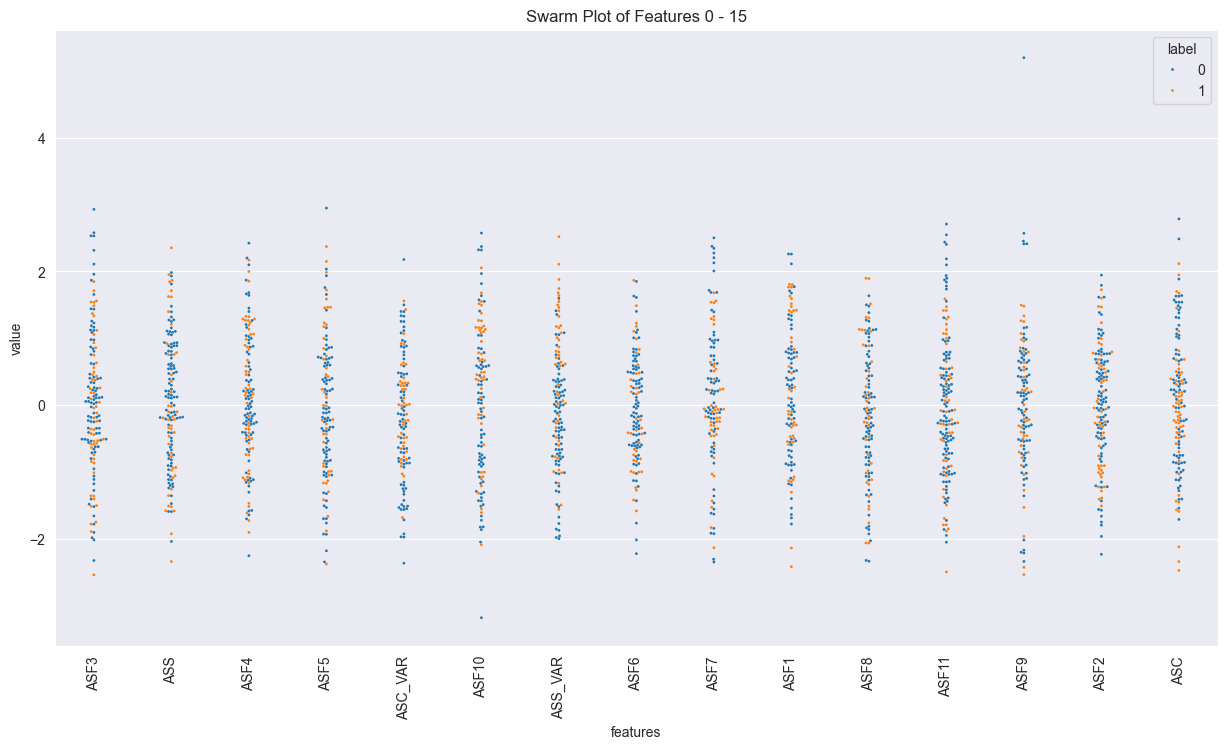

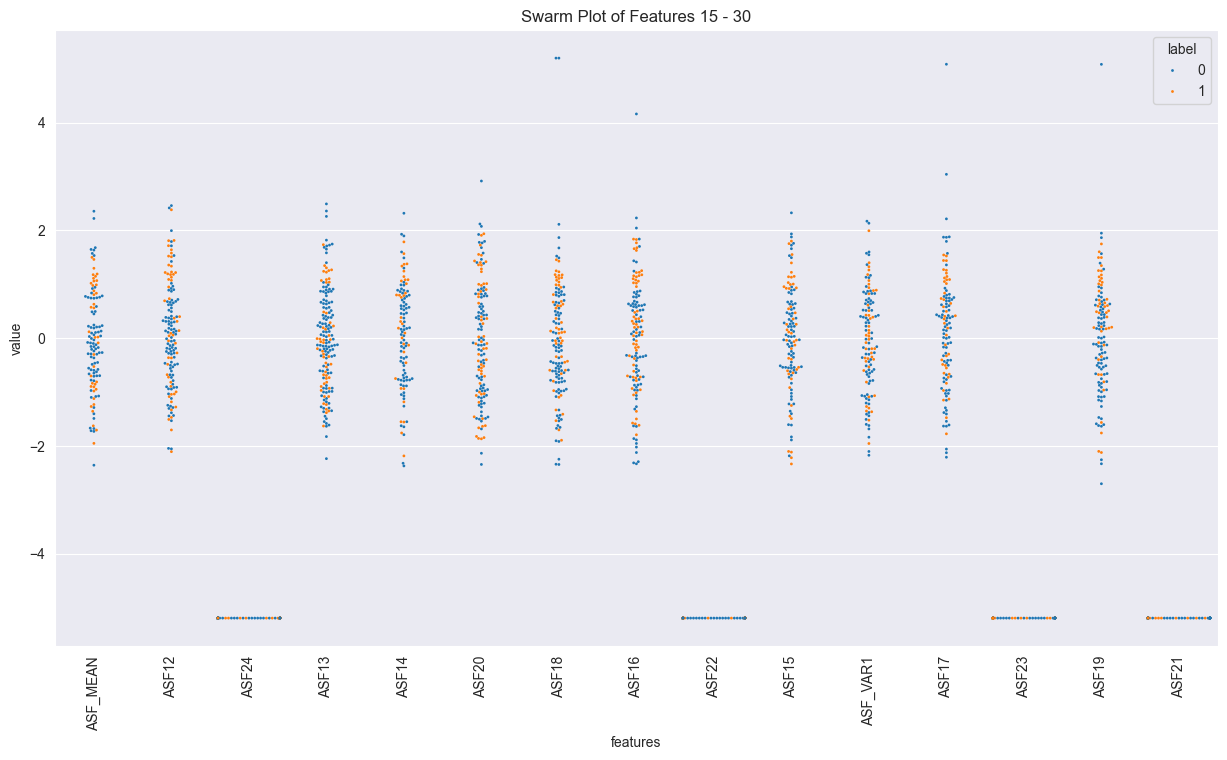

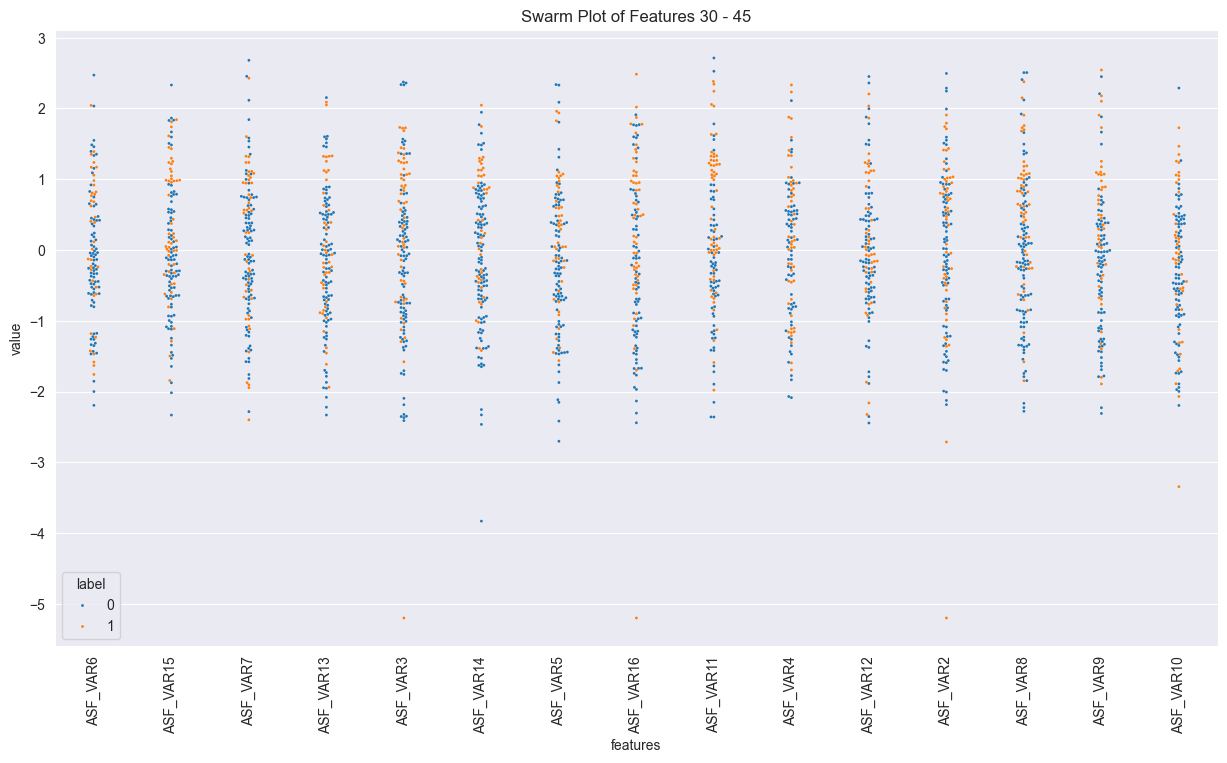

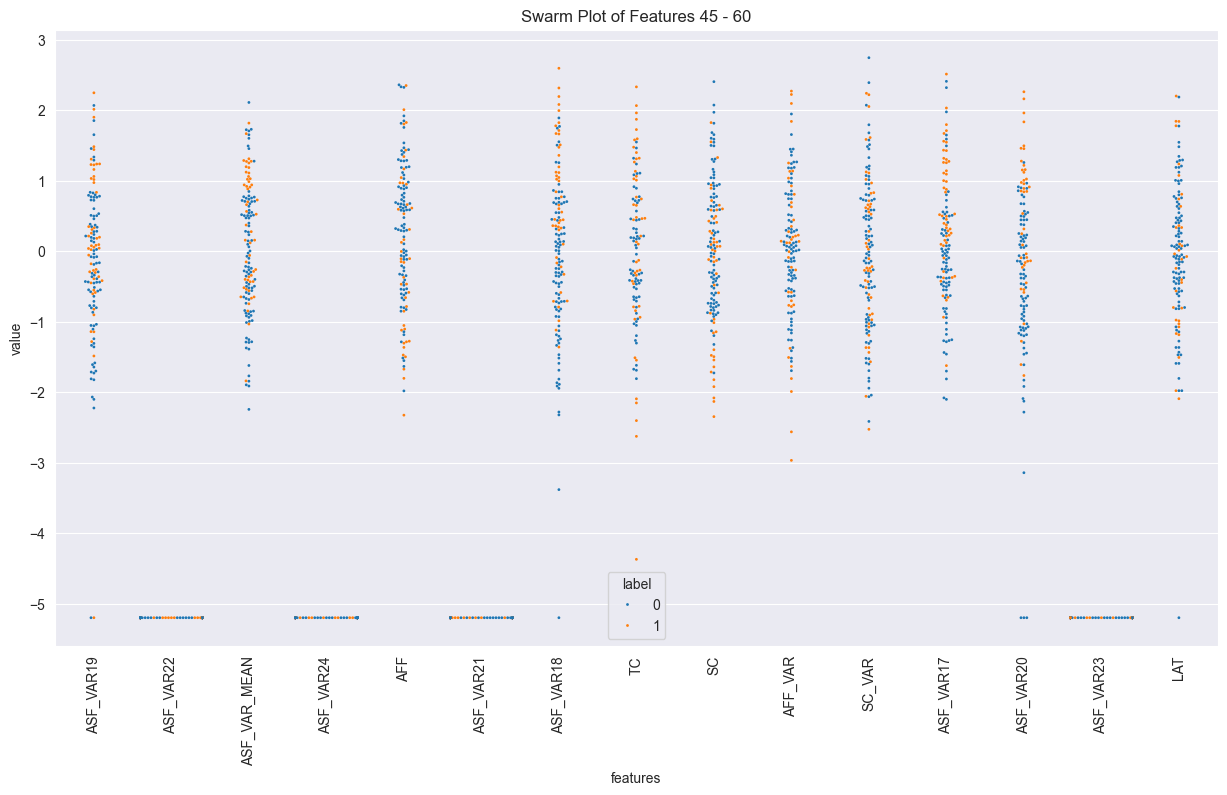

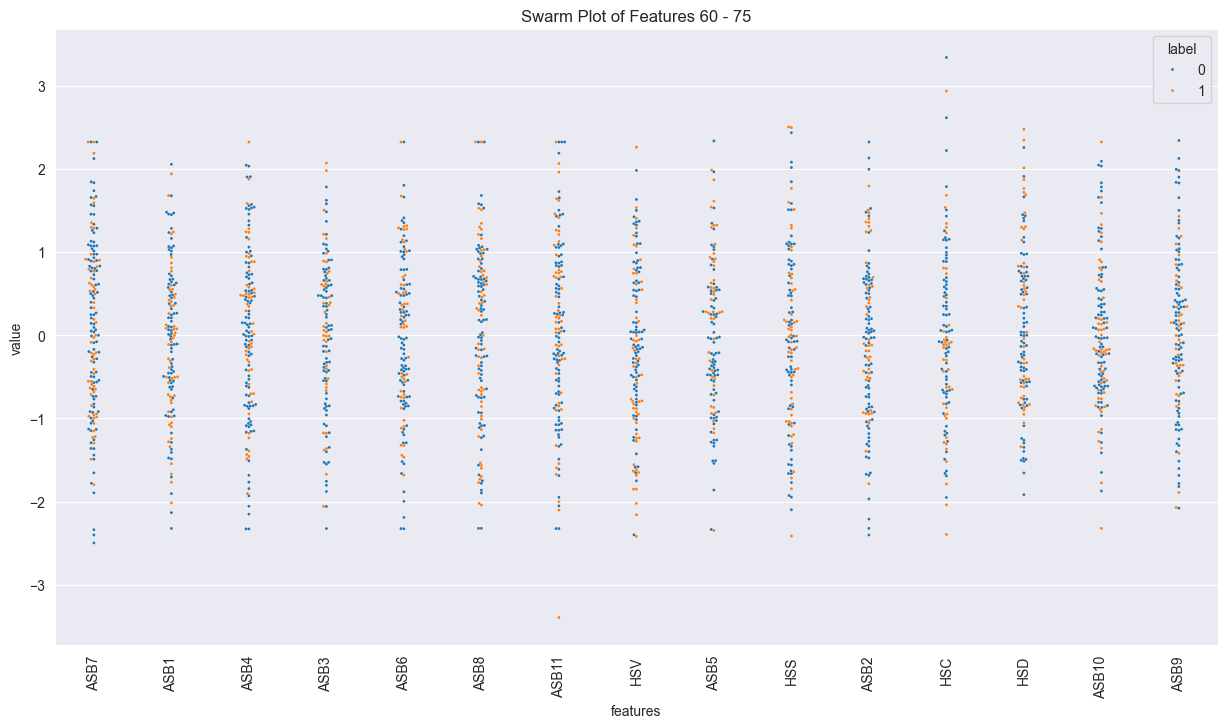

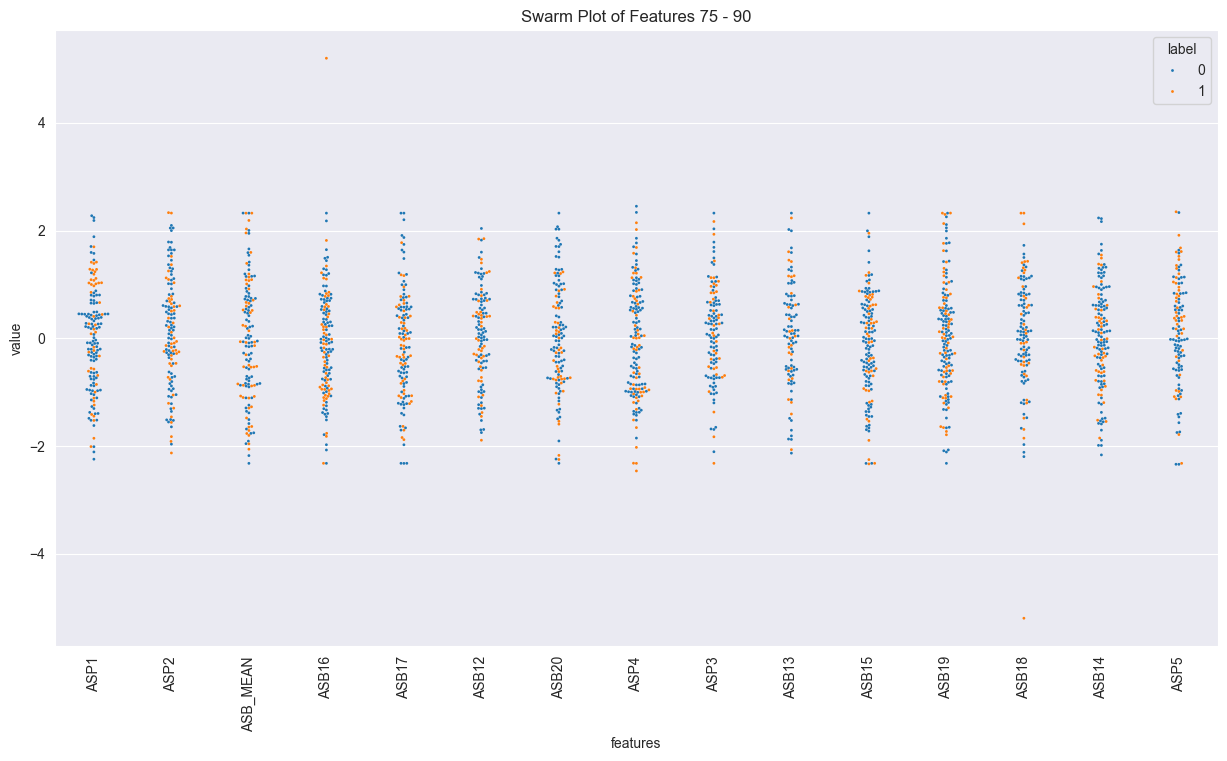

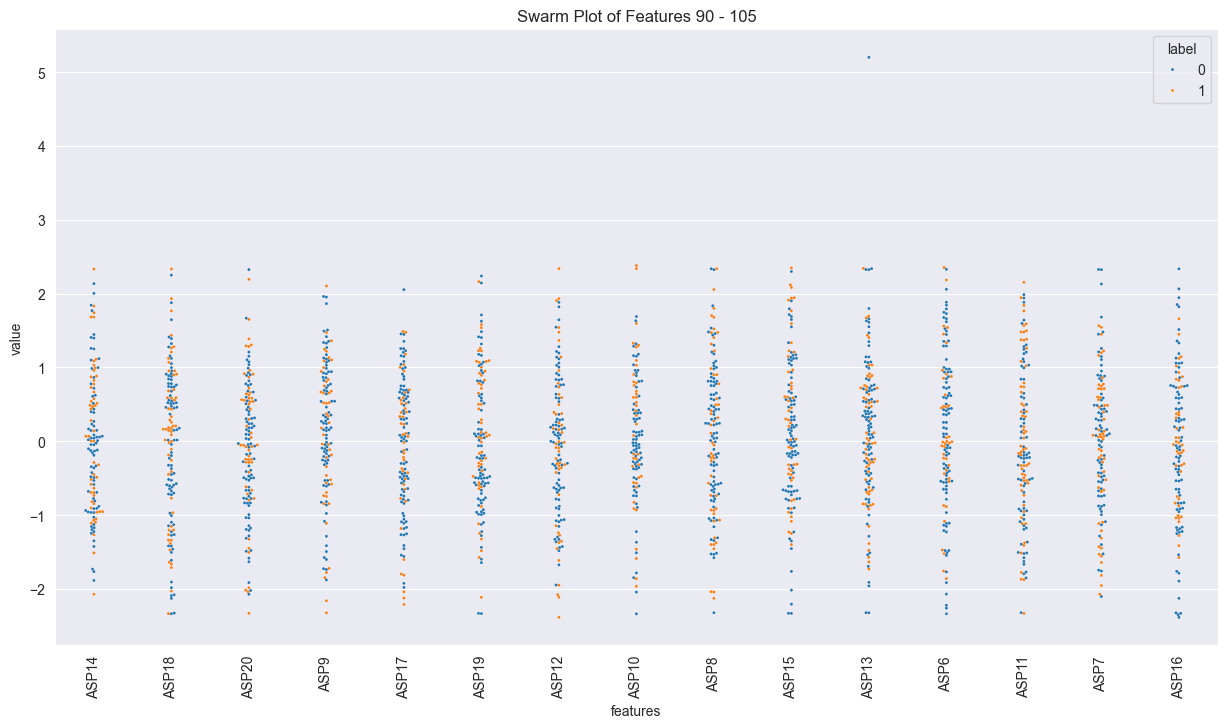

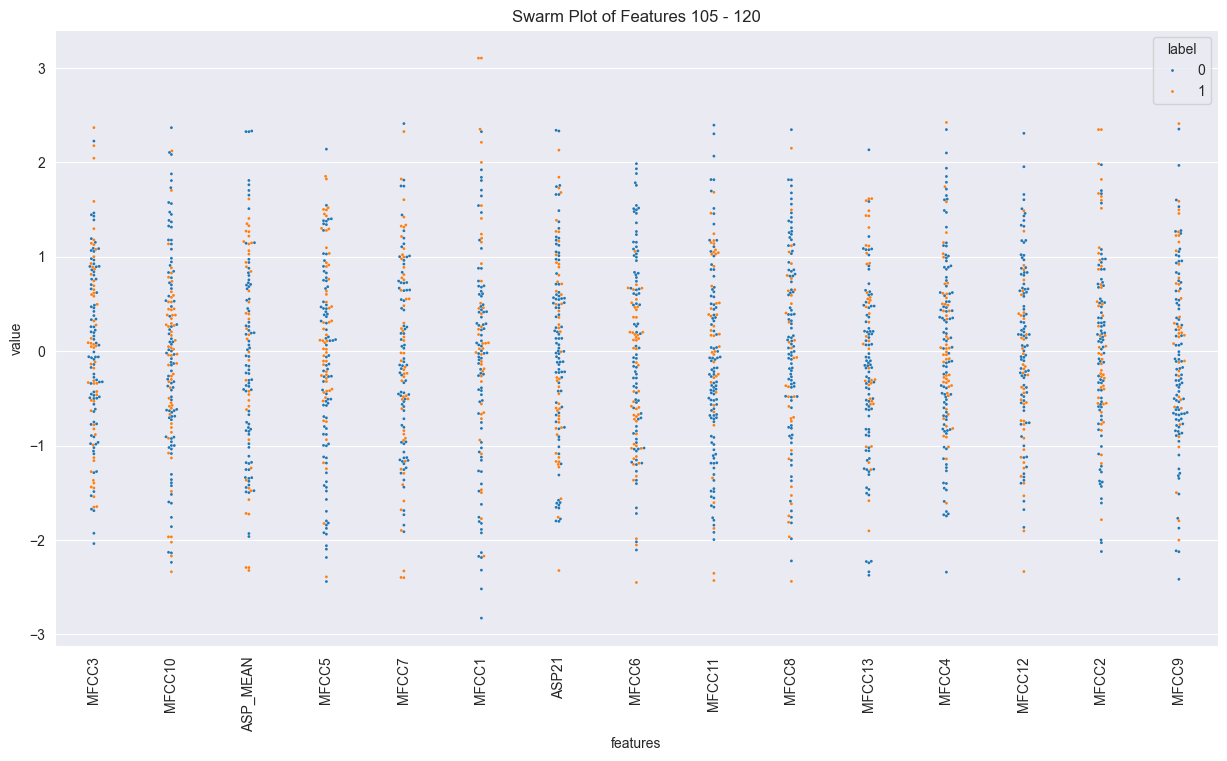

In [14]:
for i in range(8):
    plt.figure(figsize=(15, 8))
    data_ = pd.concat([y, data_2.iloc[:, indexes[i][0]:indexes[i][1]]], axis=1)
    data_ = pd.melt(data_, id_vars="label", var_name="features", value_name="value")
    data_sample = data_.sample(2000)
    sns.swarmplot(x="features", y="value", hue="label", data=data_sample, size=2)
    plt.xticks(rotation=90)
    plt.title(f"Swarm Plot of Features {indexes[i][0]} - {indexes[i][1]}")


## Z score

In [13]:
from scipy.stats import norm
def remove_z_outliers(df, features, threshold=4, label_col='label') -> pd.DataFrame:
    valid_features = [f for f in features if np.issubdtype(df[f].dtype, np.number) and df[f].std() > 0]
    if not valid_features:
        print("No valid features for outlier removal.")
        return df[[label_col]]
    z_scores = np.abs((df[valid_features] - df[valid_features].mean()) / df[valid_features].std())
    mask = (z_scores < threshold).all(axis=1)
    print(f"z-score of {threshold} corresponds to a prob of {100 * 2 * norm.sf(threshold):.6f}%")
    print(f"Rejected {(~mask).sum()} points (any feature)")
    return df.loc[mask]


### Scaling data before detecting outliers

In [12]:
data_iqr = parametrized_data.copy() 
data_iqr.isna().sum().sum()

group1_categories = ['non_word', 'short_word']
group2_categories = ['restricted_sentence', 'unrestricted_sentence']

group1_data = data_iqr[data_iqr['prompt_category'].isin(group2_categories)]
y = group1_data['label']
X = group1_data.drop('label', axis=1)
#X = X.drop('path', axis=1)
X = X.drop('prompt_category', axis=1)
scaler_outliers = StandardScaler()
data_iqr = scaler_outliers.fit_transform(X)



In [14]:
features = list(X.columns)

data_iqr = pd.concat([y.reset_index(drop=True), pd.DataFrame(data_iqr, columns=X.columns)], axis=1)
data_cleaned = remove_z_outliers(data_iqr, features, threshold=4)
data_cleaned = data_cleaned.reset_index(drop = True)
data_cleaned.isna().sum().sum()


z-score of 4 corresponds to a prob of 0.006334%
Rejected 320 points (any feature)


0

## Detecting outliers with IQR

In [15]:
def iqr_capping(df, cols, factor):
    
    for col in cols:
        
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        
        iqr = q3 - q1
        
        upper_whisker = q3 + (factor*iqr)
        lower_whisker = q1 - (factor*iqr)
        
        df[col] = np.where(df[col]>upper_whisker, upper_whisker,
                 np.where(df[col]<lower_whisker, lower_whisker, df[col]))

In [60]:
# iqr_capping(data_cleaned, features, 1.5)

### Separating data again

In [62]:
# from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler,  MaxAbsScaler, PowerTransformer,QuantileTransformer
# scaler = QuantileTransformer(n_quantiles=100, output_distribution='normal')
# X_clipped = data_cleaned.drop(columns=['label'])
# scaler = StandardScaler()
# X_clipped = scaler.fit_transform(X_clipped)
# data_clipped = pd.DataFrame(X_clipped, columns=parametrized_data.columns[1:])

In [16]:
y = data_cleaned['label']
X = data_cleaned.drop('label', axis=1)

### Violin plot

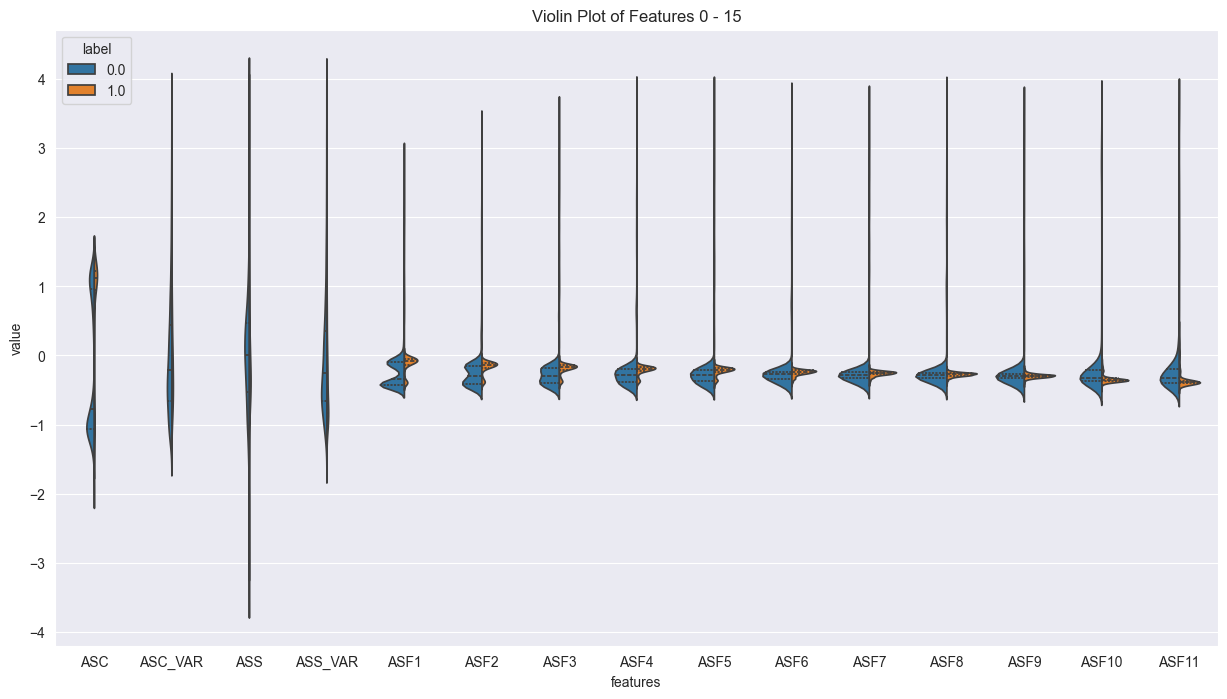

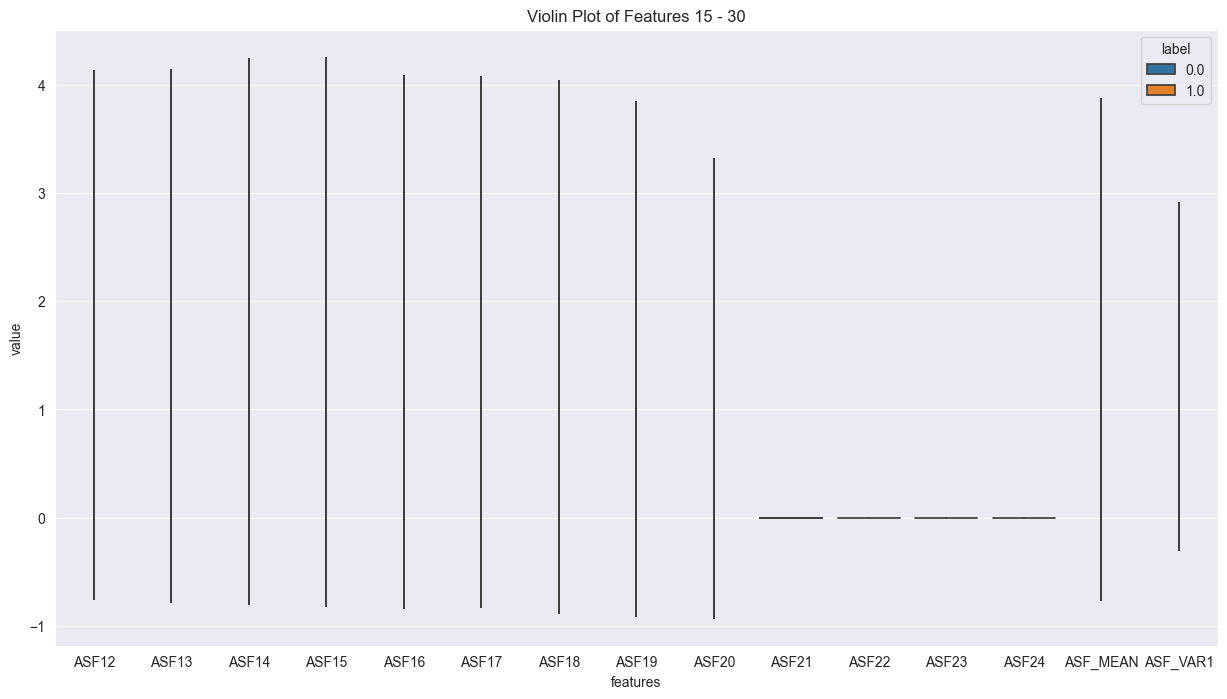

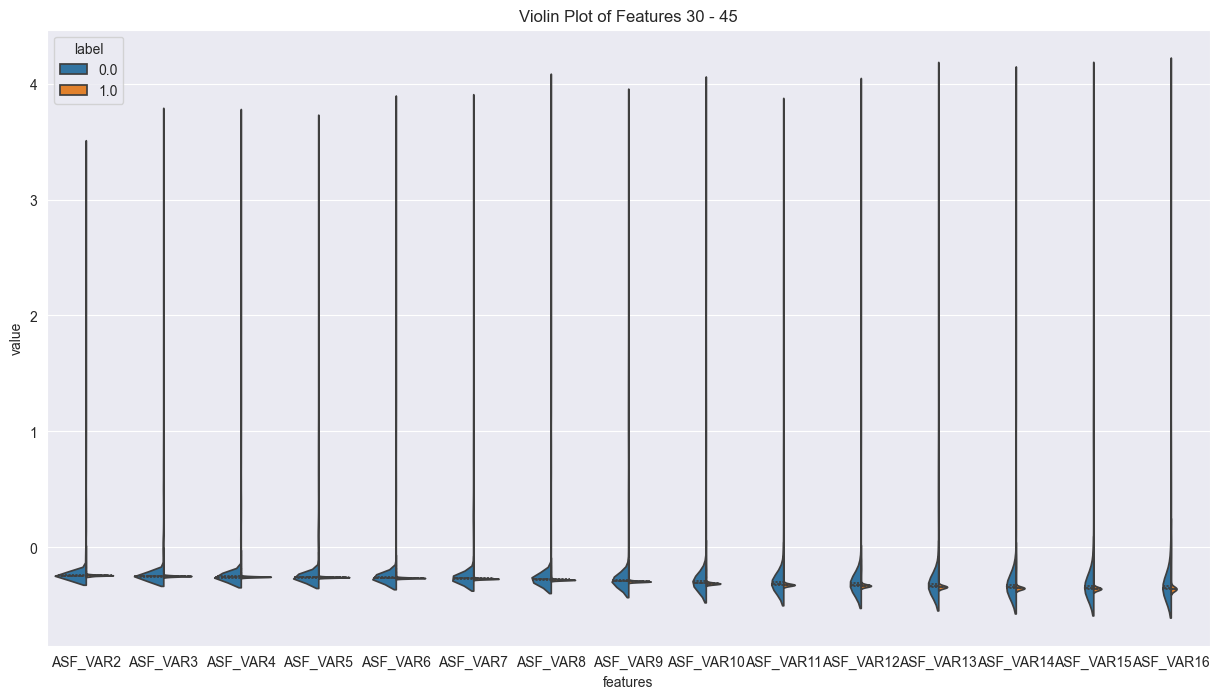

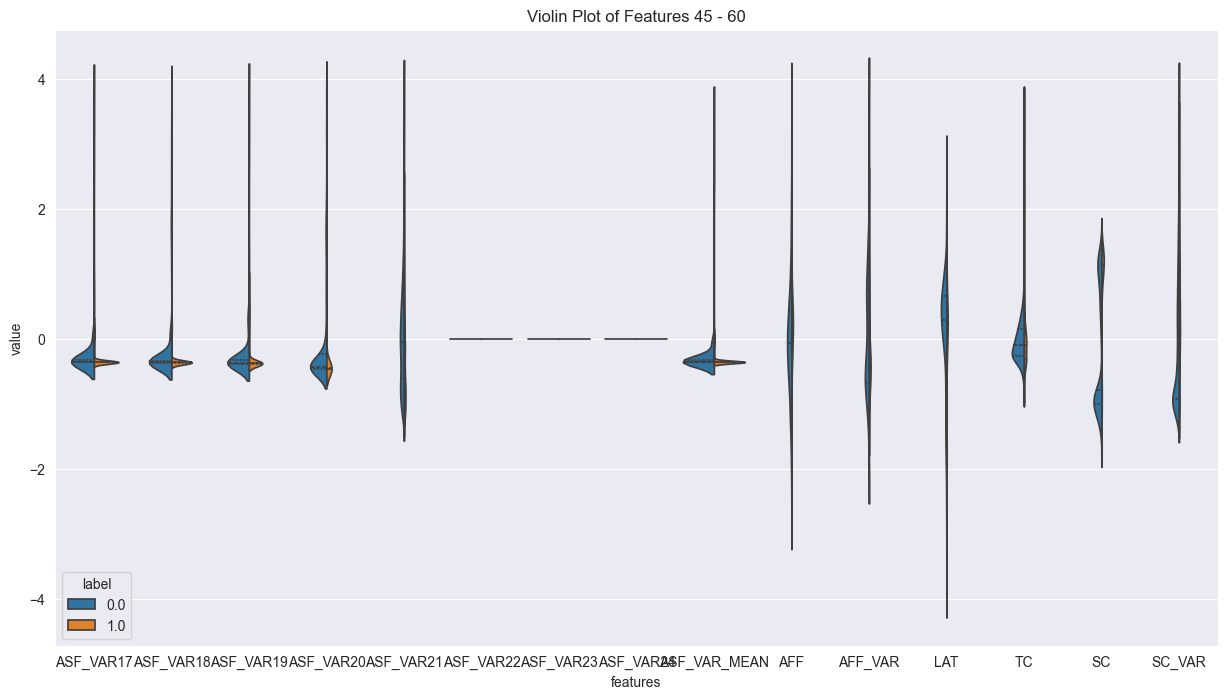

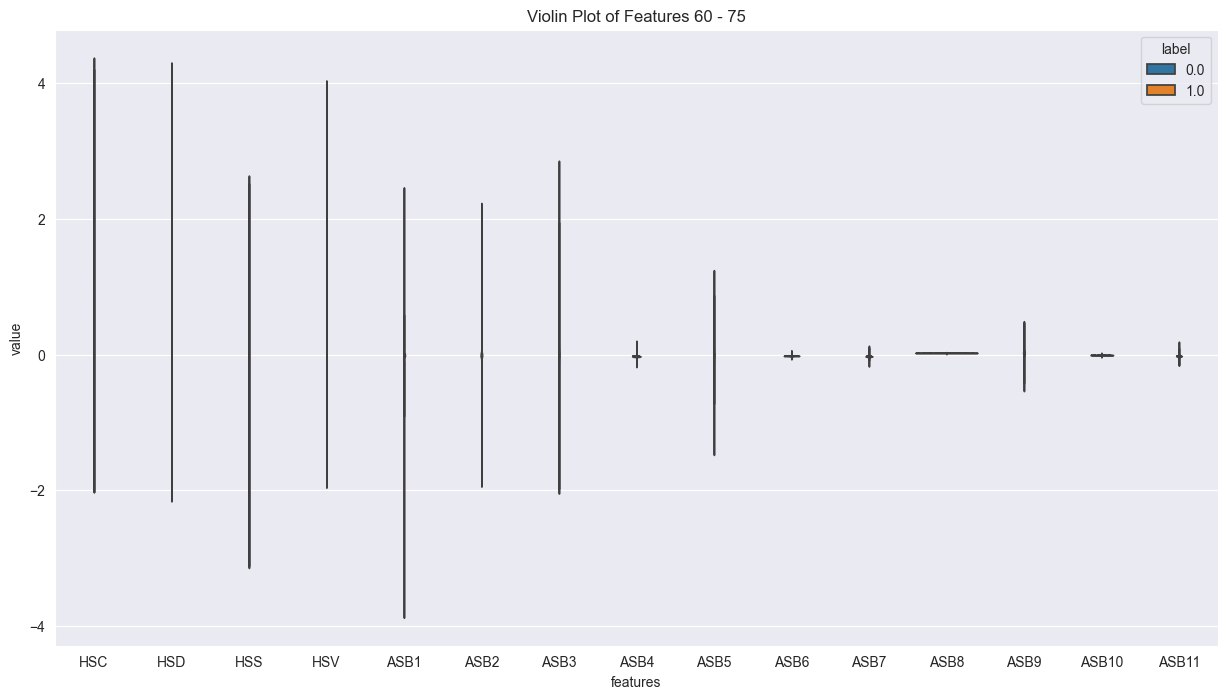

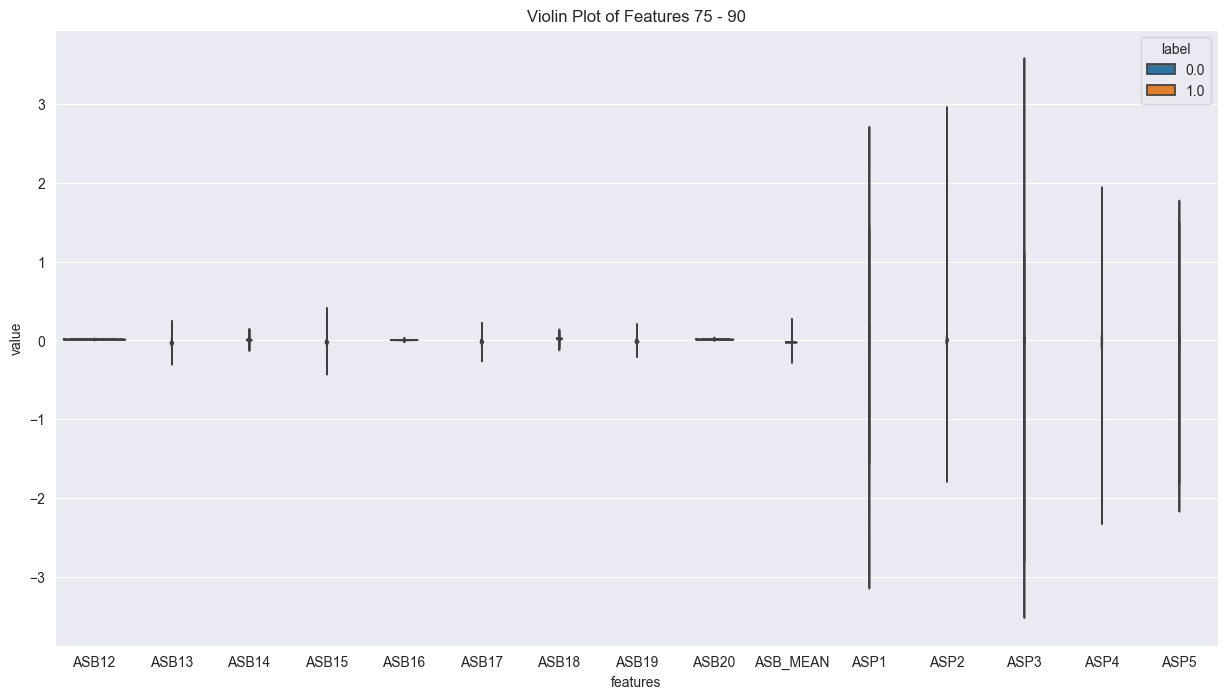

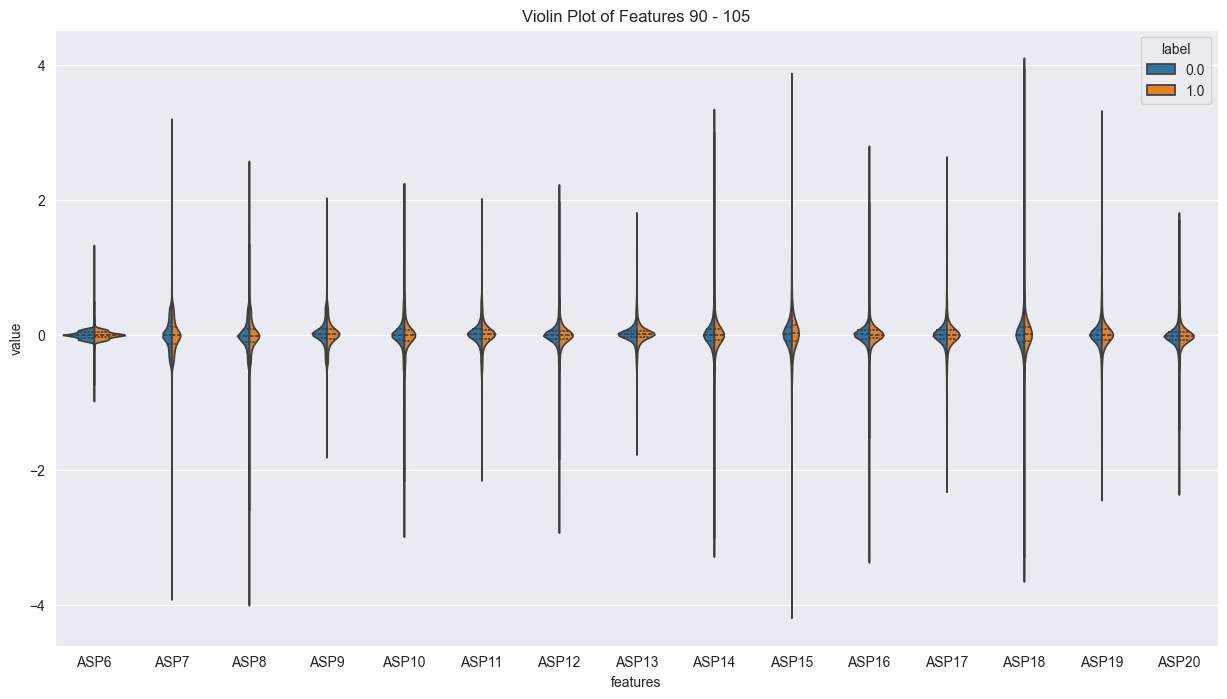

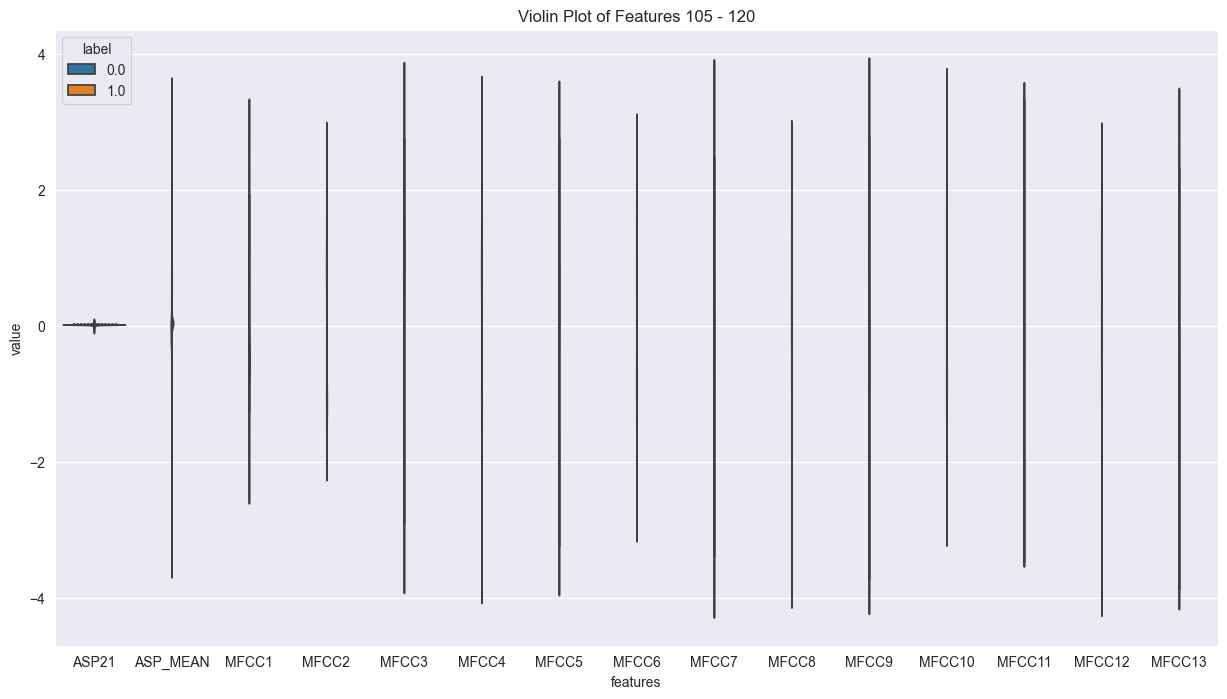

In [33]:
for i in range(8):
    plt.figure(figsize=(15, 8))
    data_ = pd.concat([y, X.iloc[:, indexes[i][0]:indexes[i][1]]], axis=1)
    data_ = pd.melt(data_, id_vars="label", var_name="features", value_name="value")
    sns.violinplot(x="features", y="value", hue="label", data=data_,
                   split=True, inner="quart")
    plt.title(f"Violin Plot of Features {indexes[i][0]} - {indexes[i][1]}")

### Box plots of clipped data

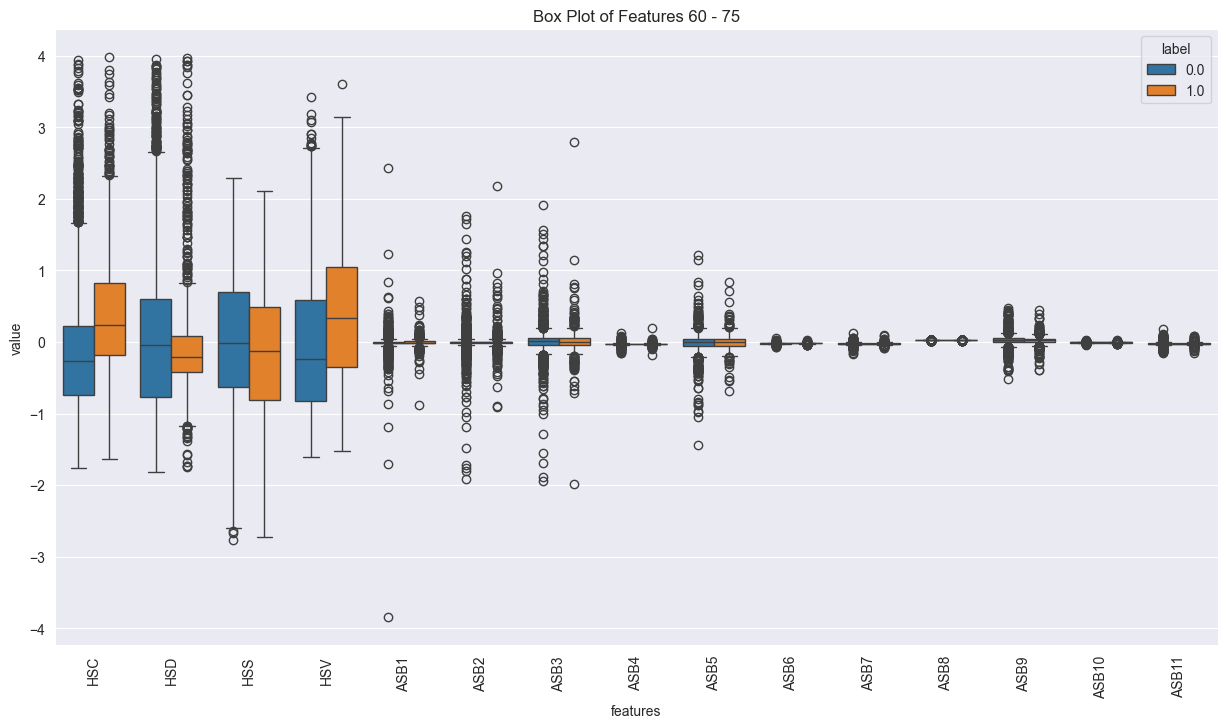

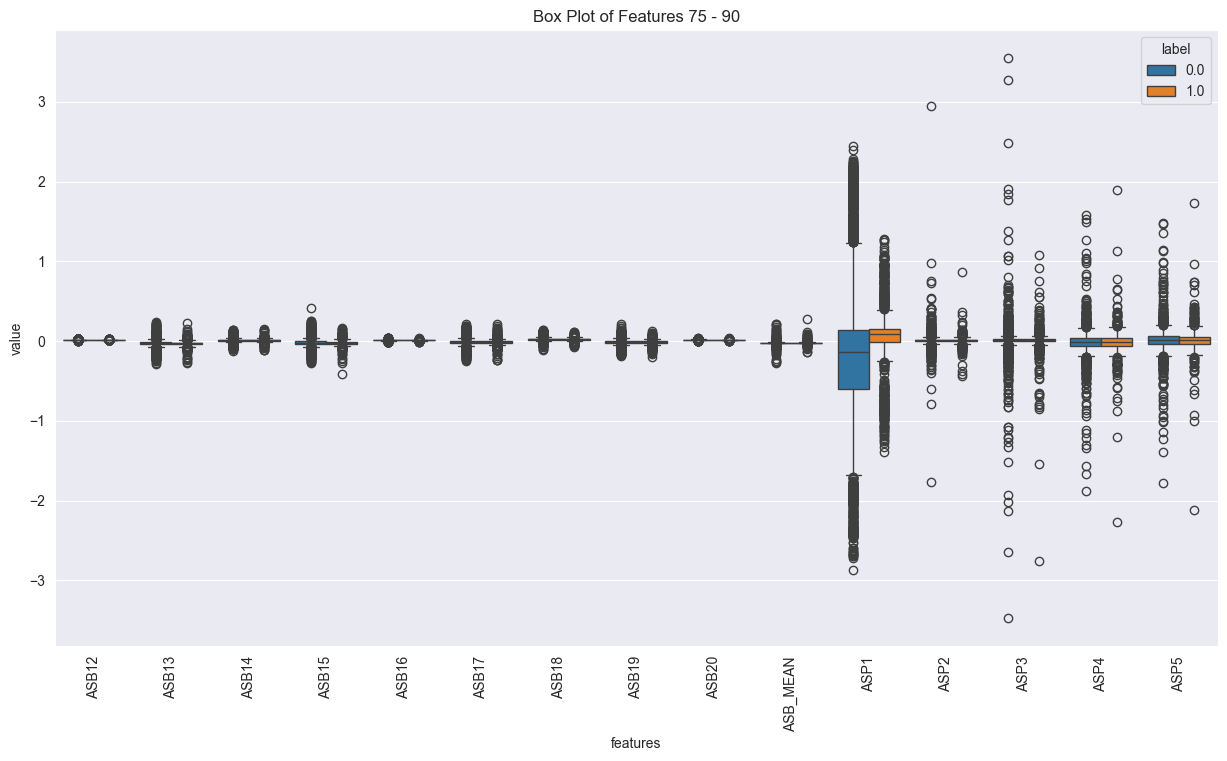

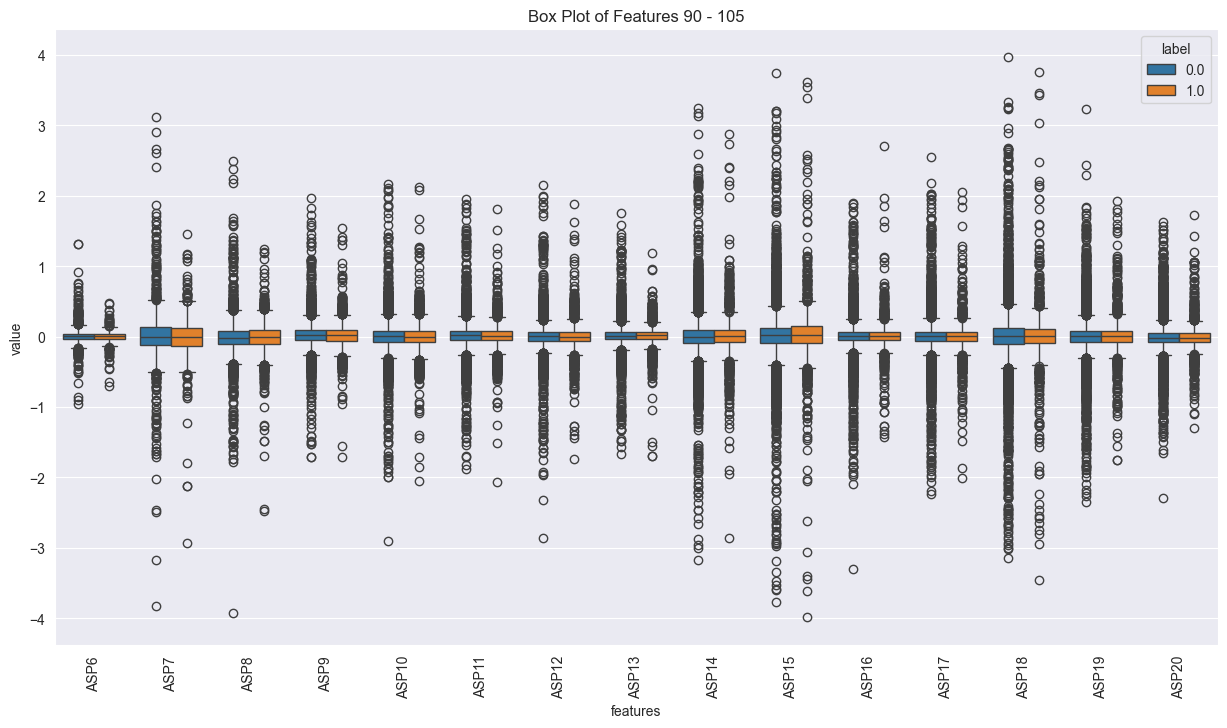

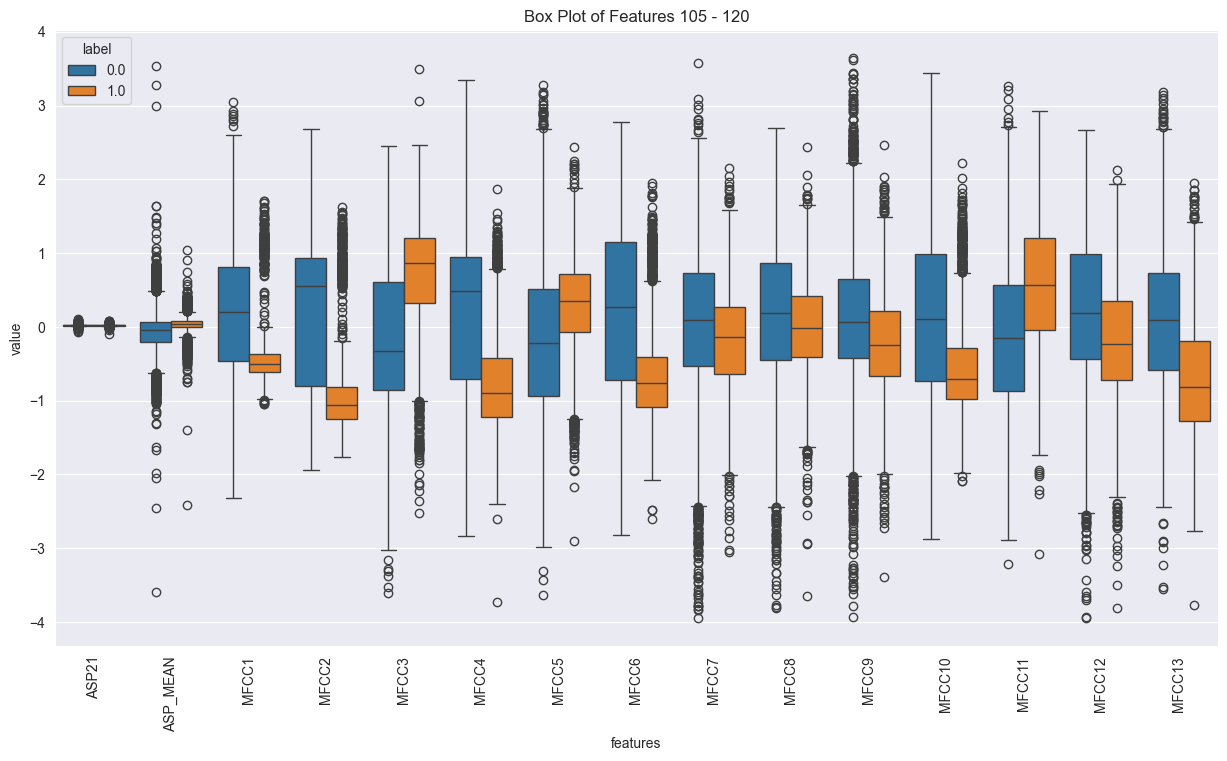

In [34]:
for i in range(4,8):
    plt.figure(figsize=(15, 8))
    data_ = pd.concat([y, X.iloc[:, indexes[i][0]:indexes[i][1]]], axis=1)
    data_ = pd.melt(data_, id_vars="label", var_name="features", value_name="value")
    sns.boxplot(x="features", y="value", hue="label", data=data_)
    plt.xticks(rotation=90)
    plt.title(f"Box Plot of Features {indexes[i][0]} - {indexes[i][1]}")

### Removing outliers with Isolation Forest

In [17]:
from sklearn.ensemble import IsolationForest

X = scaler_outliers.inverse_transform(X)
isolation_forest = IsolationForest(random_state=42 ,n_jobs=-1)
isolation_forest.fit(X,y)
predictions = isolation_forest.predict(X)
print("Predictions: \n", predictions[:20])
print("Outlier count: \n", len(predictions[predictions == -1]))
print("Inlier count: \n", len(predictions[predictions == 1]))
decision_scores = isolation_forest.decision_function(X)
print("Decision scores: \n", decision_scores[:20])
print("Decision scores shape:", decision_scores.shape)
decision_scores_df = pd.DataFrame(decision_scores, columns=['decision_scores'])
decision_scores_df.sort_values(by='decision_scores', ascending=False, inplace=True)
decision_scores_df.head()


Predictions: 
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Outlier count: 
 250
Inlier count: 
 3768
Decision scores: 
 [0.12977284 0.12746688 0.11190721 0.10244173 0.13376876 0.12315574
 0.1373452  0.11986443 0.10720087 0.13053224 0.14051728 0.09908327
 0.10481658 0.08681784 0.12511153 0.12902895 0.13539546 0.13757879
 0.12863845 0.11893994]
Decision scores shape: (4018,)


,decision_scores
512,0.152793
2242,0.152692
1739,0.152385
258,0.152123
340,0.151972


In [18]:
X_clipped = X[np.where(predictions == 1, True, False)]
y_clipped = y[np.where(predictions == 1,True, False)]
data_clipped= pd.DataFrame(X_clipped, columns=parametrized_data.columns[2:])
len(y_clipped)
# len(X_clipped)

3768

### Box plots of data after Forest Isolation

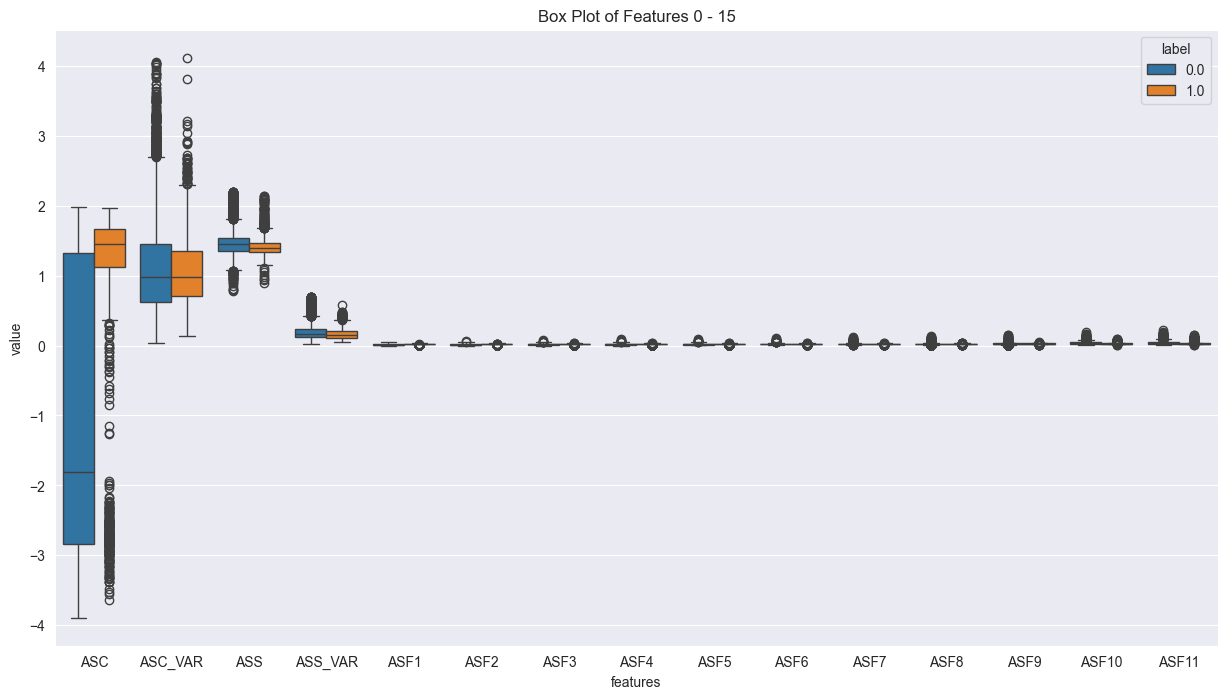

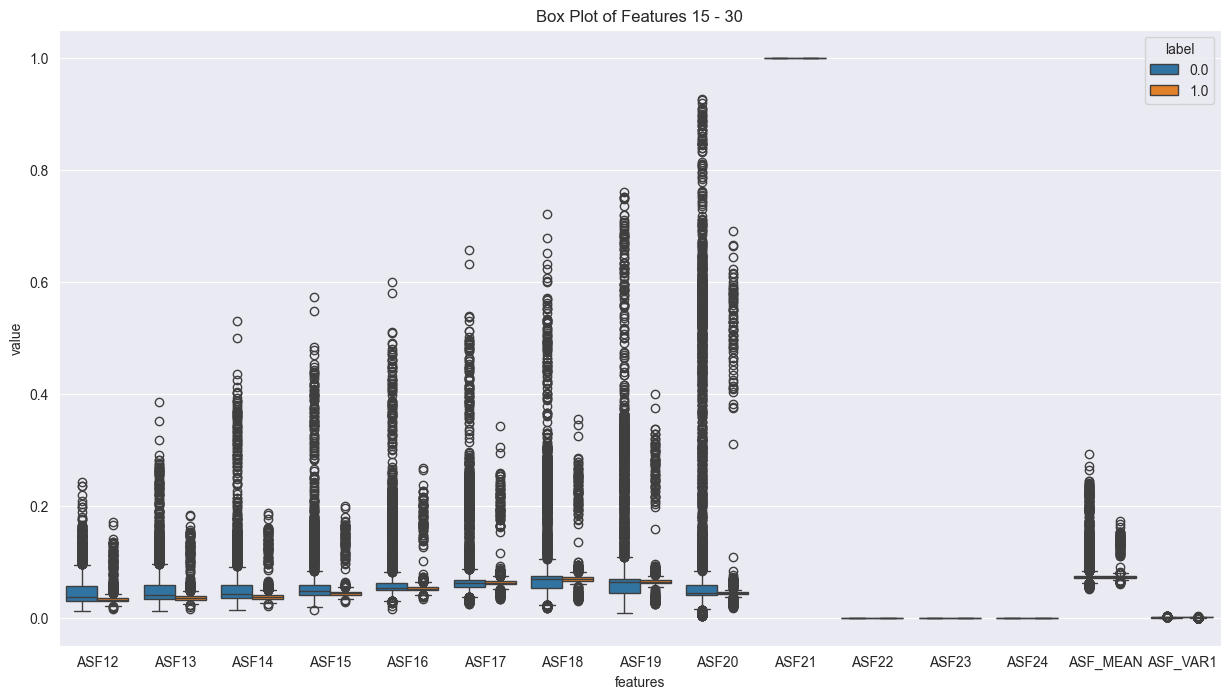

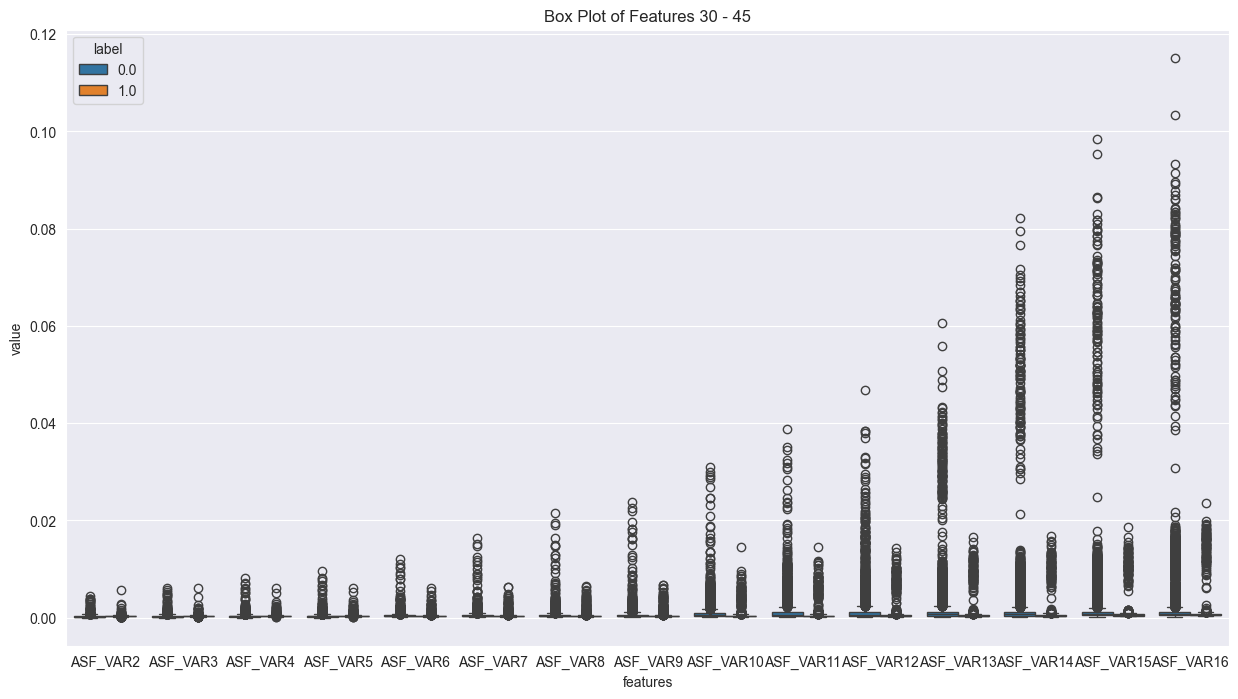

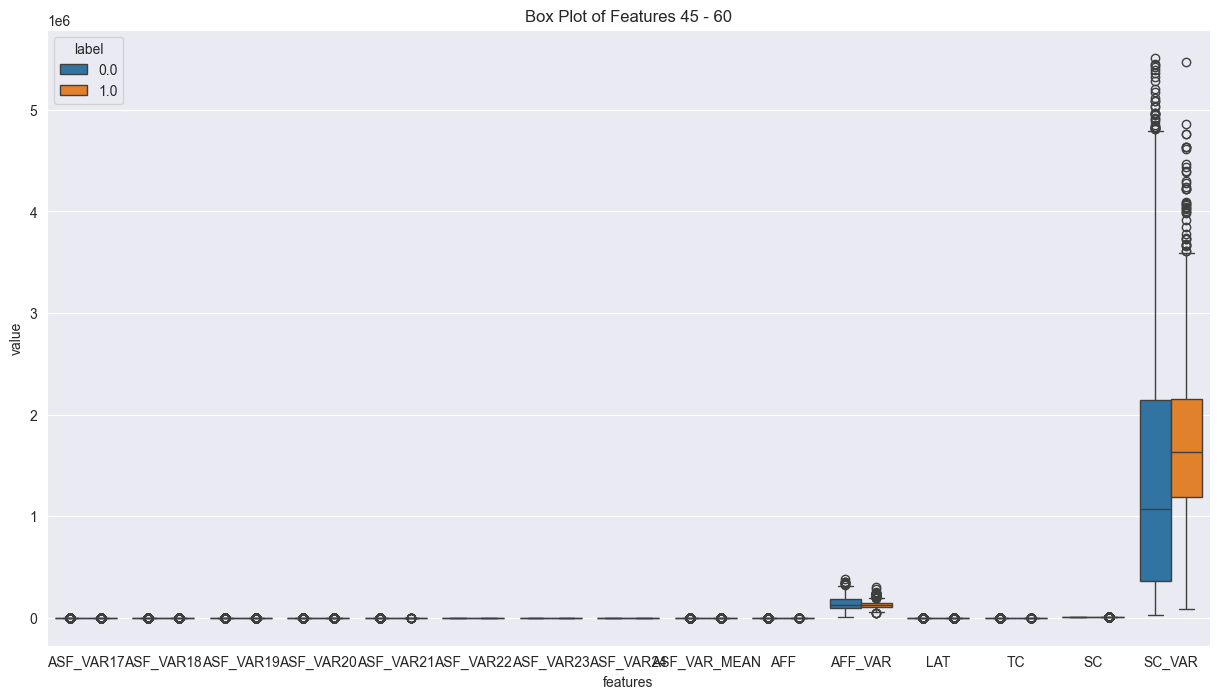

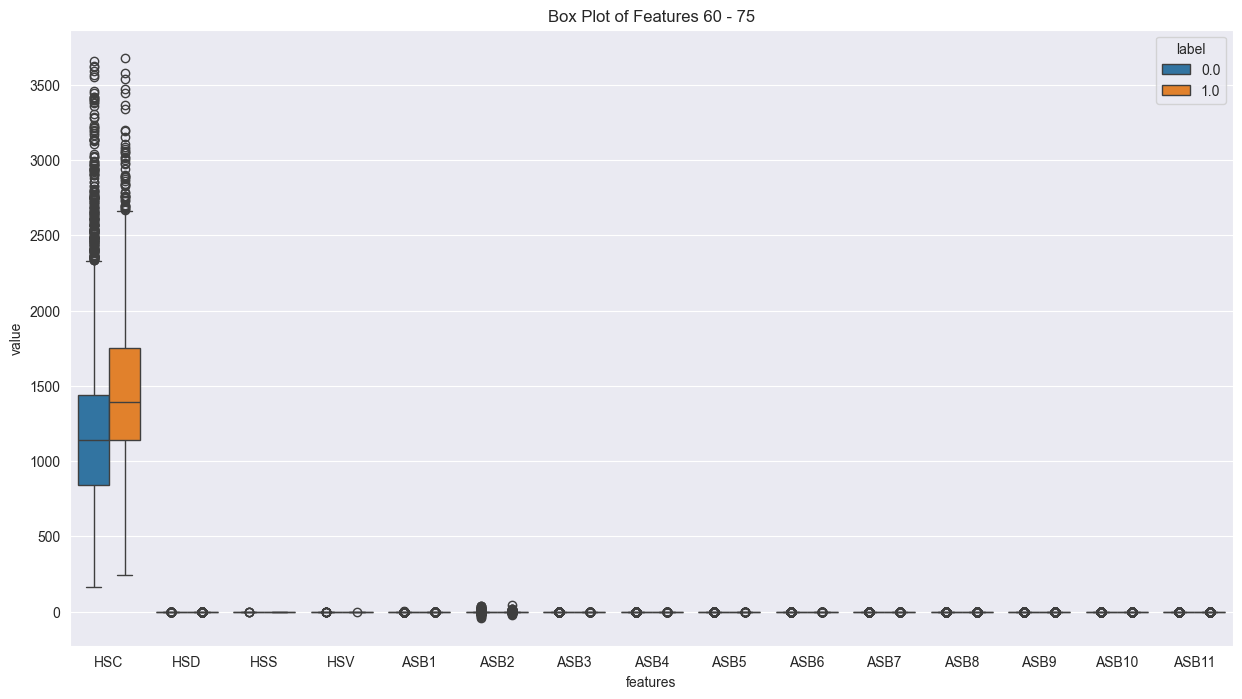

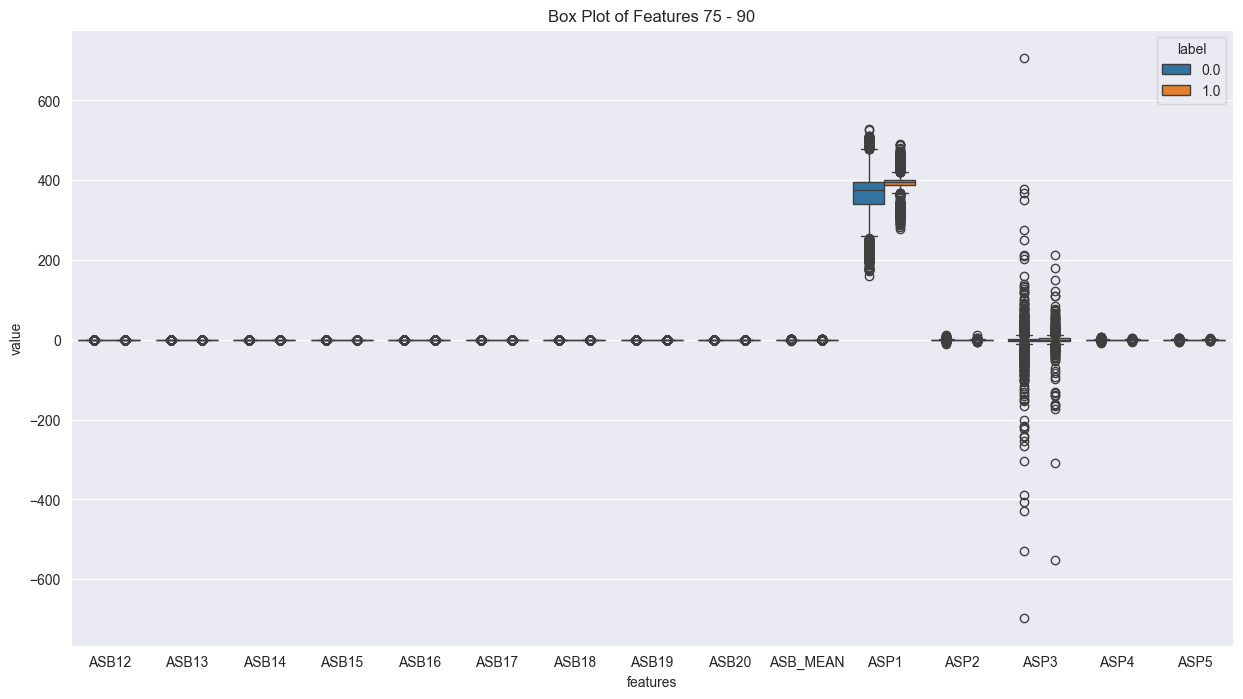

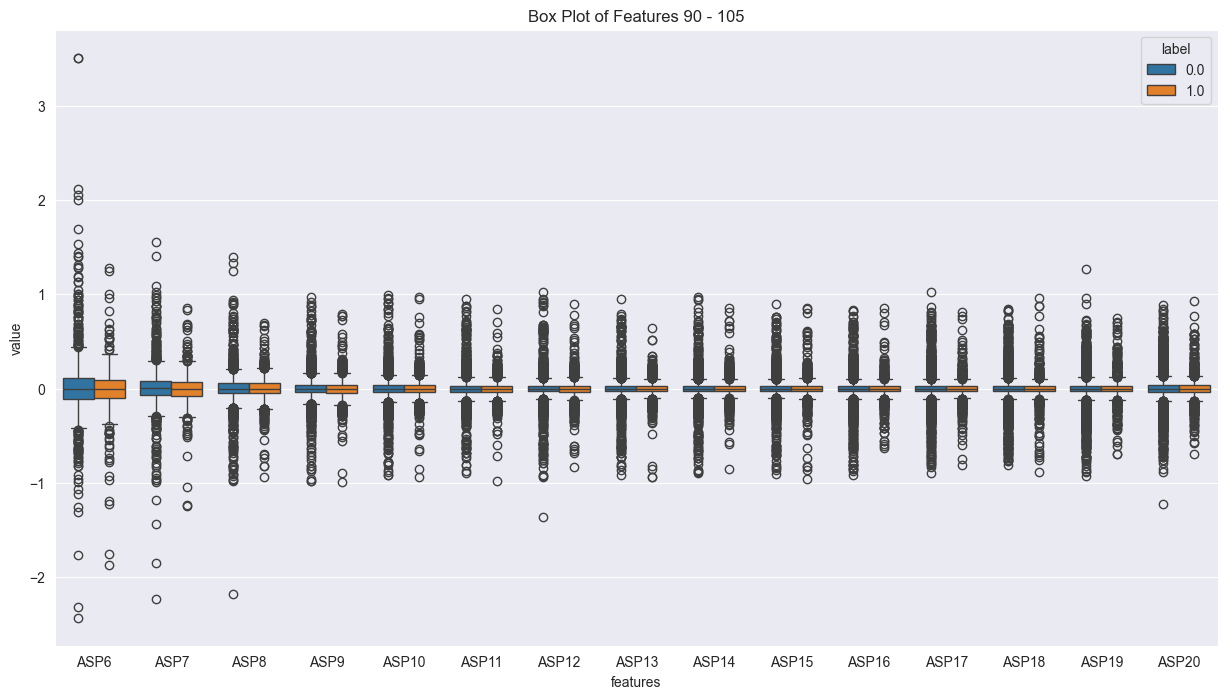

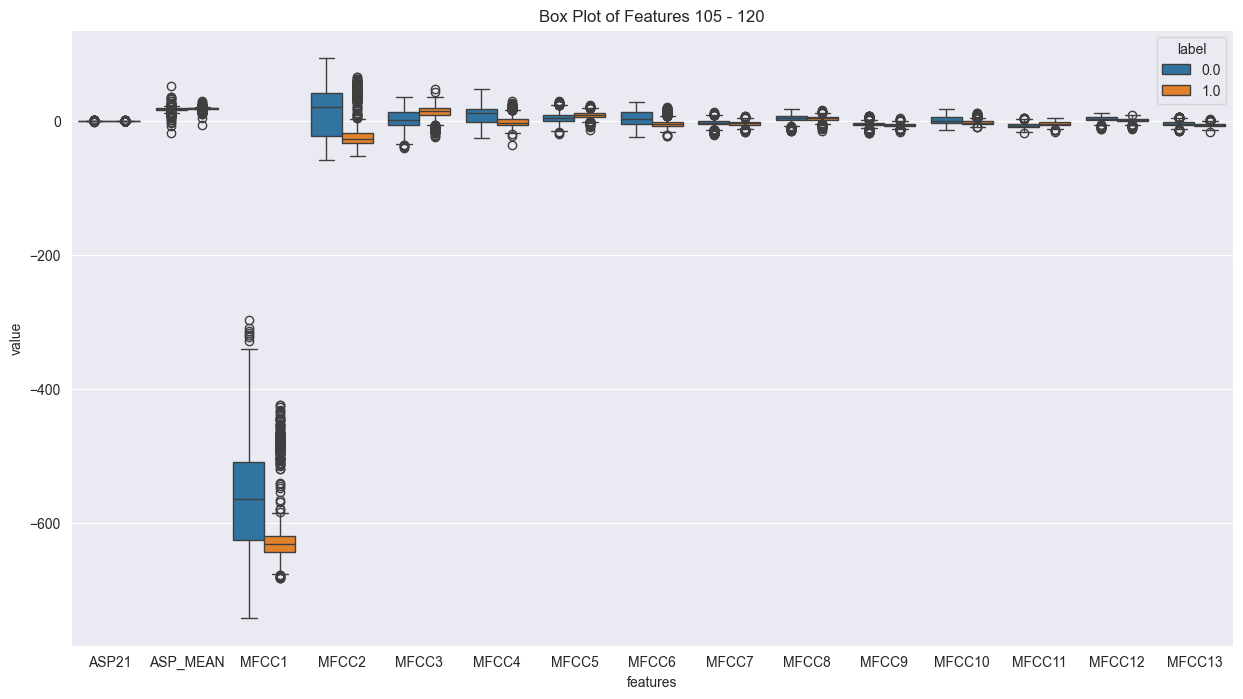

In [38]:
for i in range(8):
    plt.figure(figsize=(15, 8))
    data_ = pd.concat([y, data_clipped.iloc[:, indexes[i][0]:indexes[i][1]]], axis=1)
    data_ = pd.melt(data_, id_vars="label", var_name="features", value_name="value")
    sns.boxplot(x="features", y="value", hue="label", data=data_)
    plt.title(f"Box Plot of Features {indexes[i][0]} - {indexes[i][1]}")

### Violing Plots of data after Isolation Forest

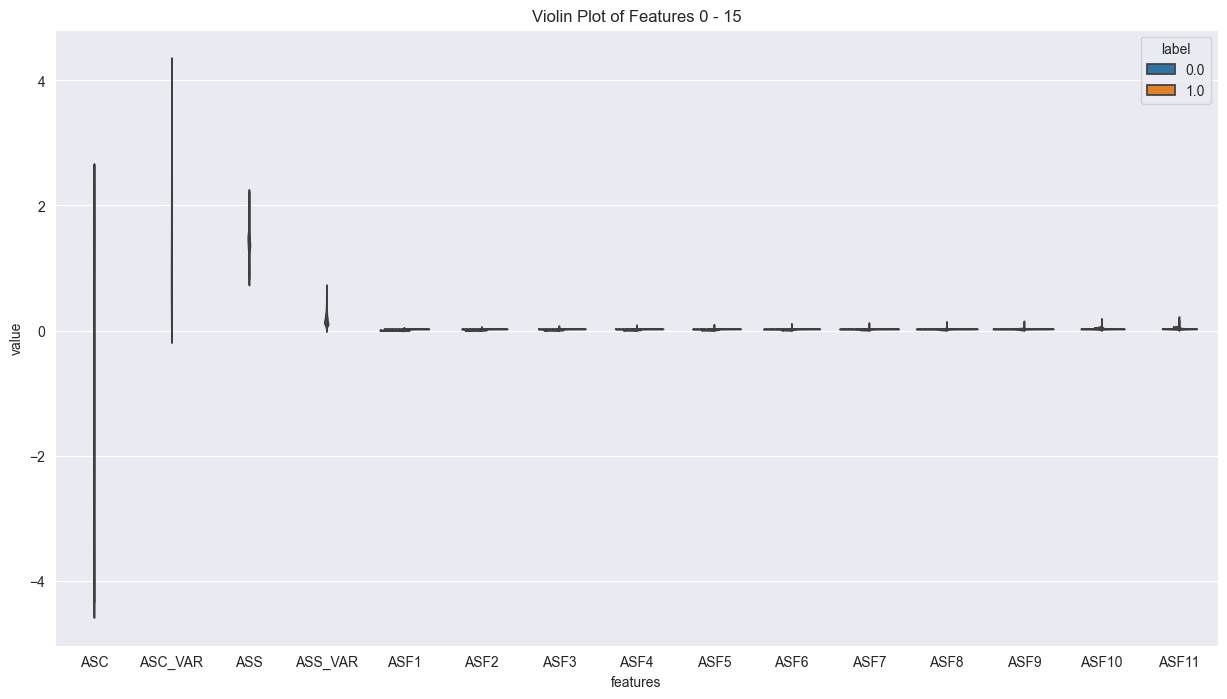

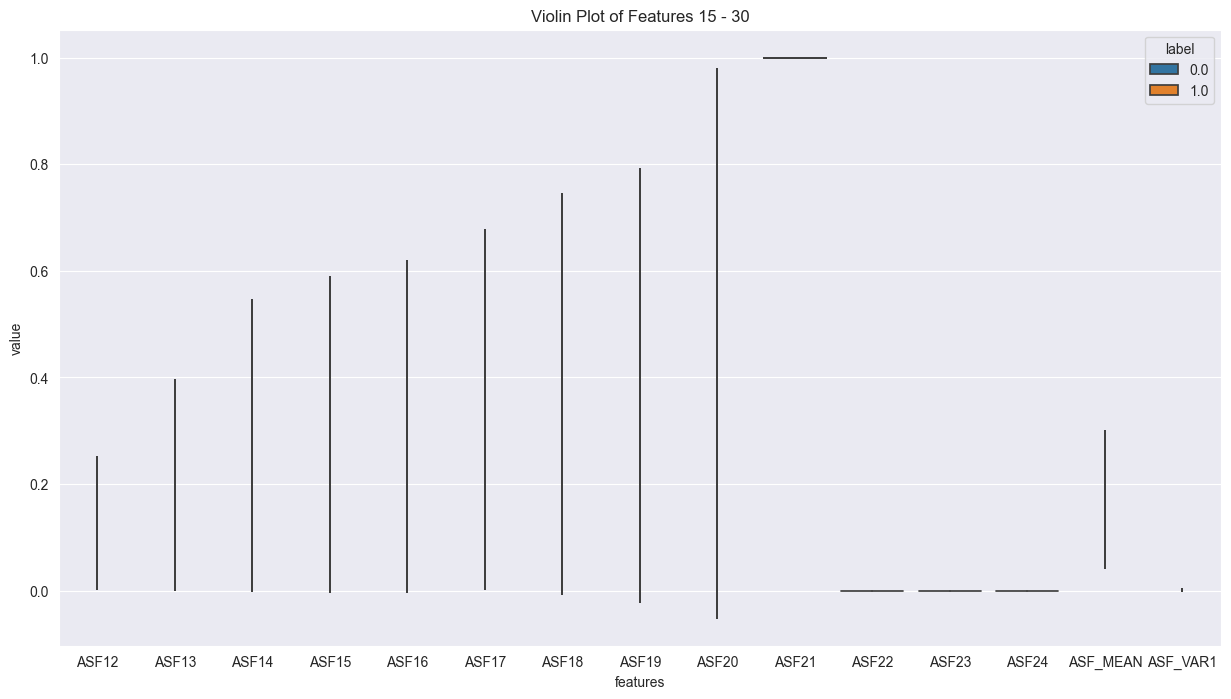

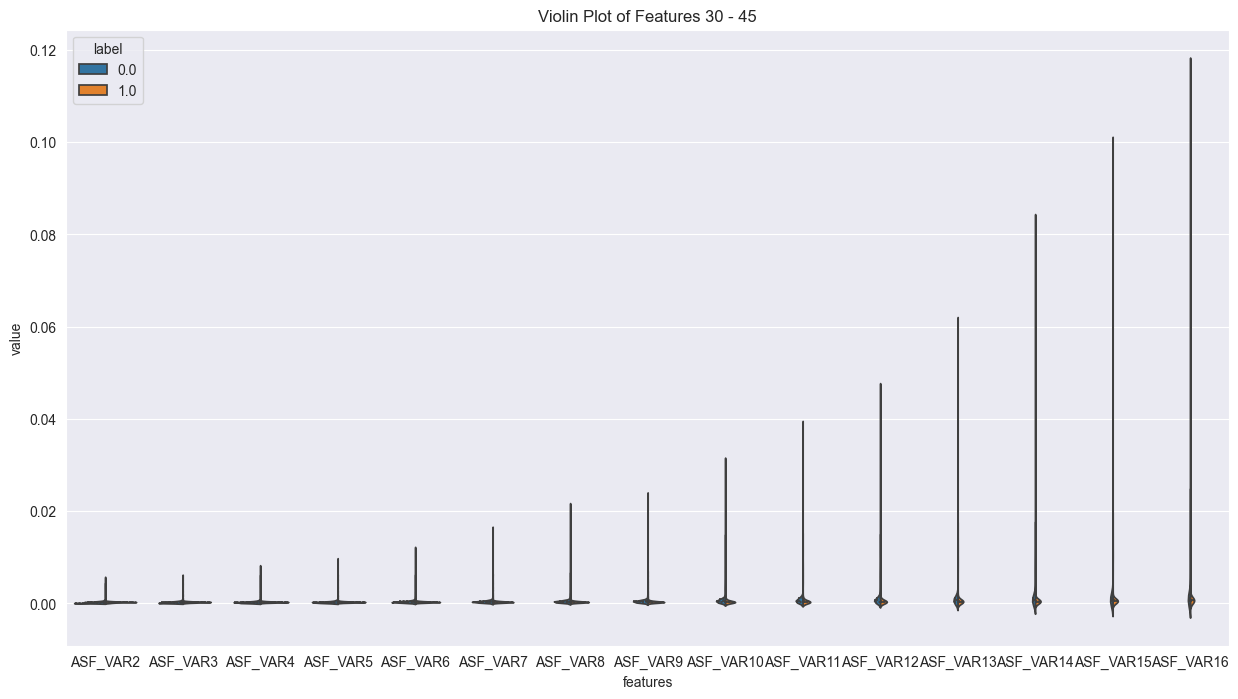

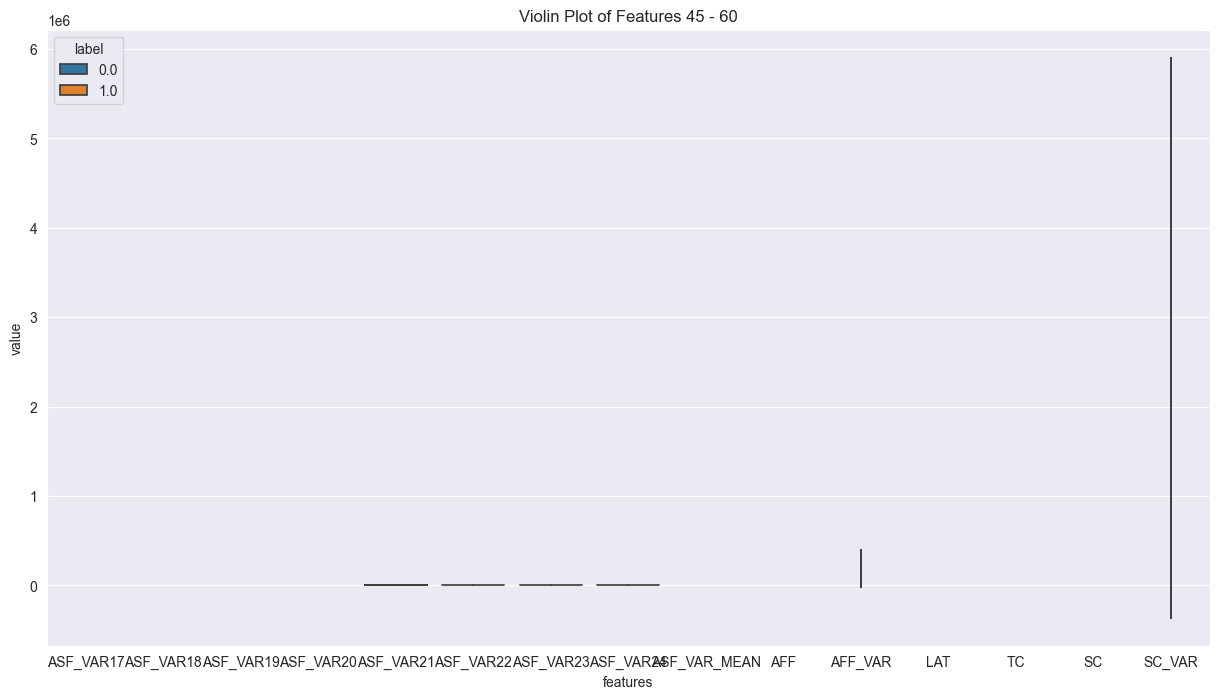

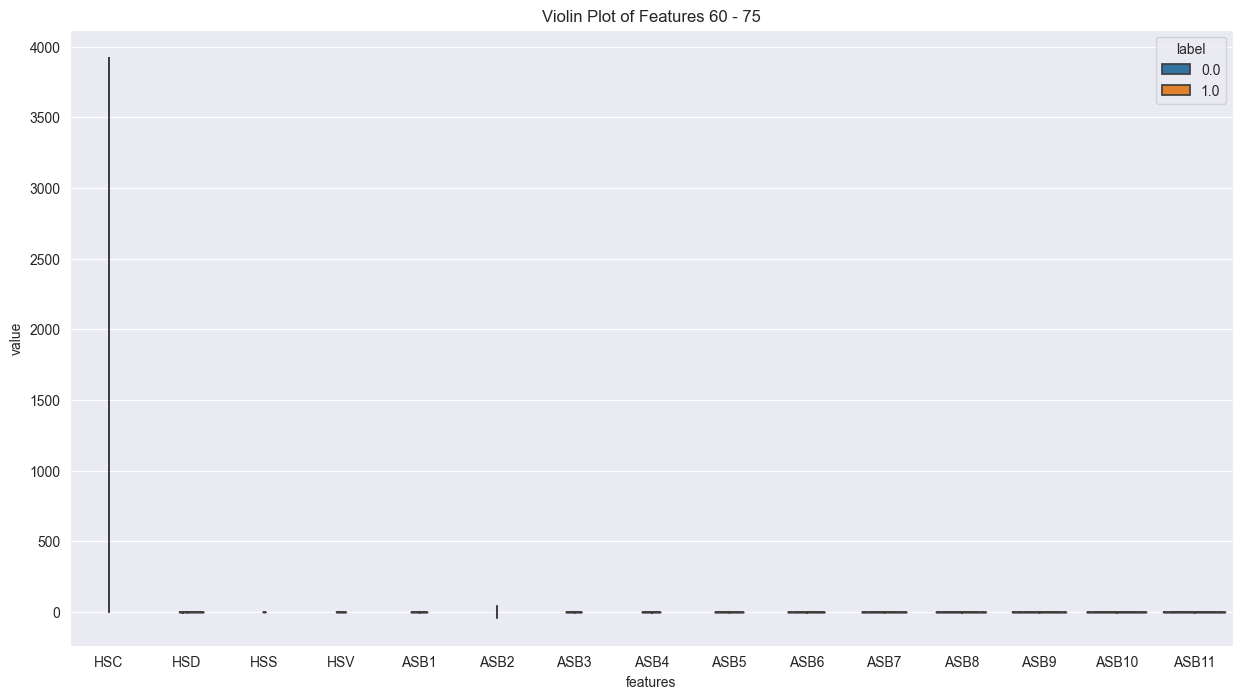

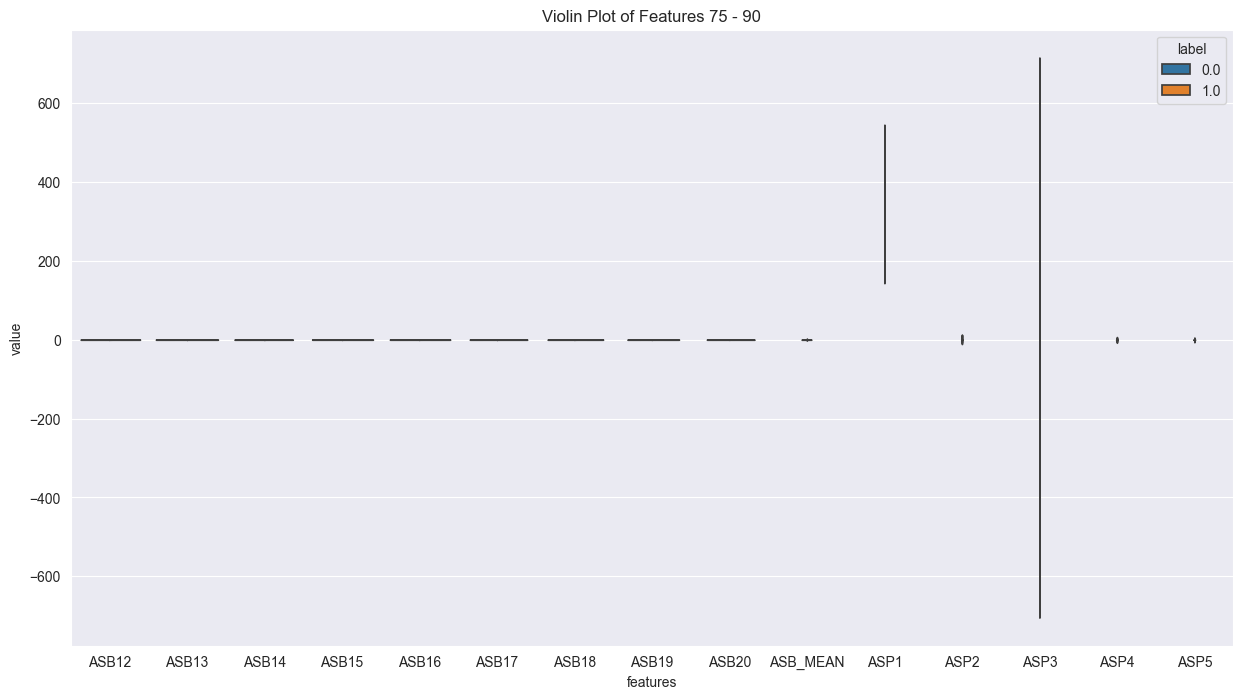

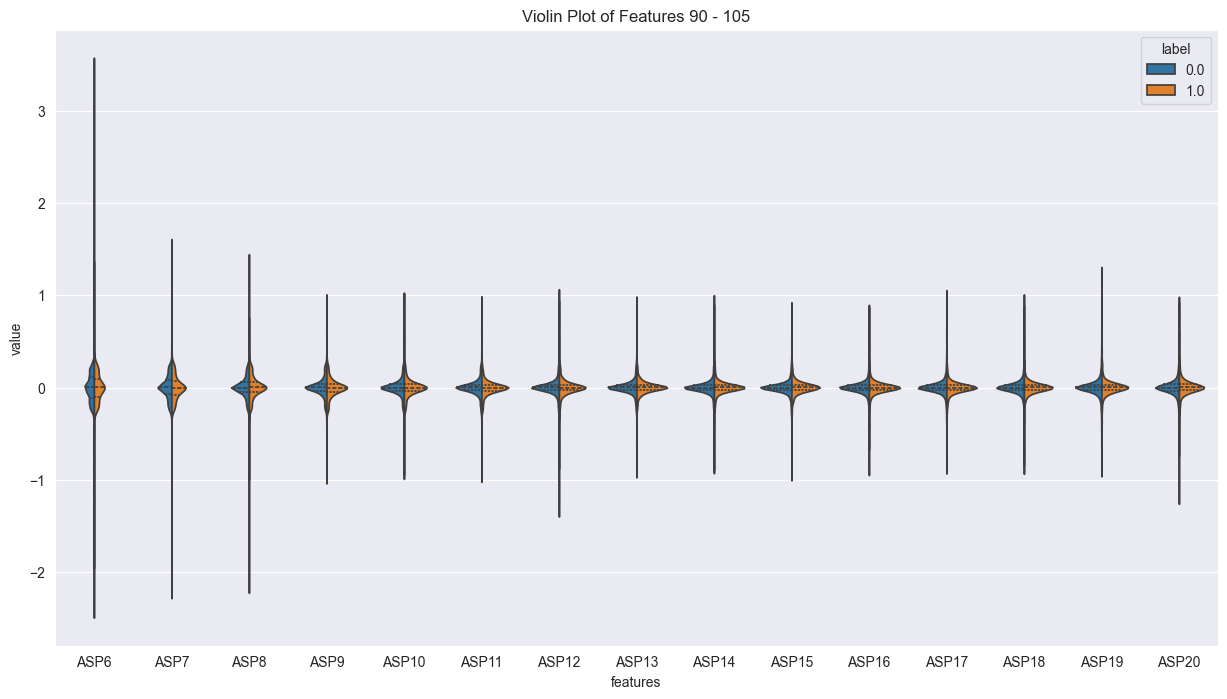

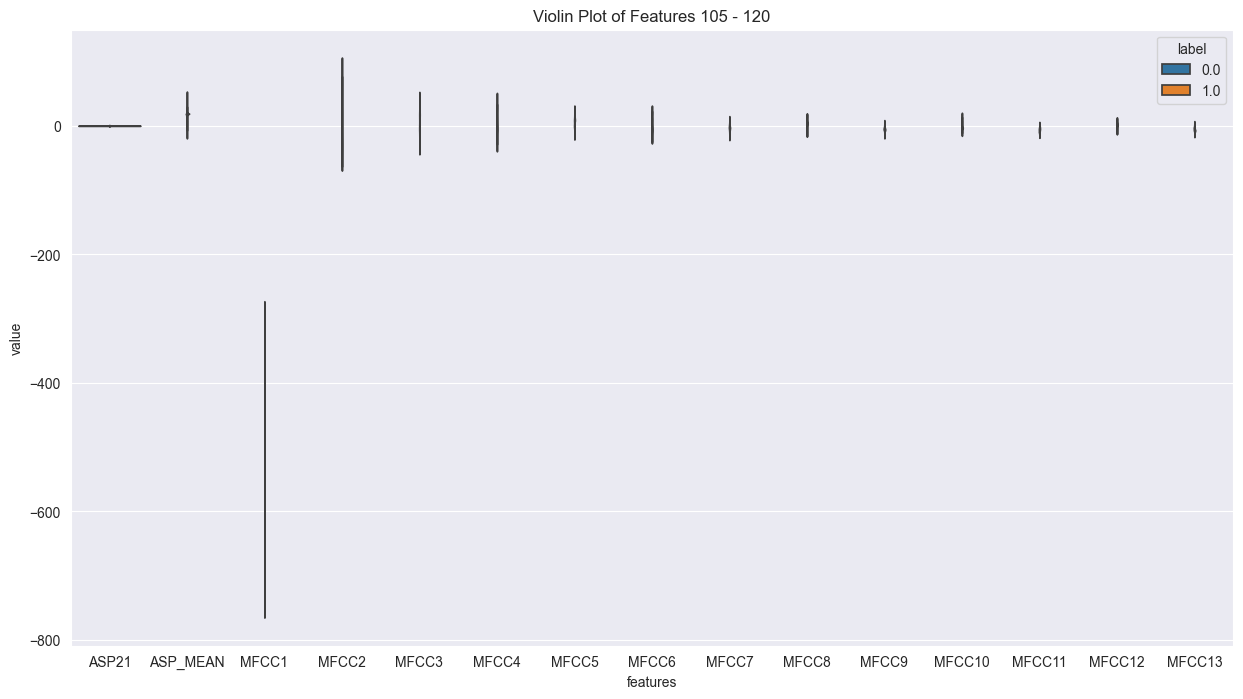

In [39]:
for i in range(8):
    plt.figure(figsize=(15, 8))
    data_ = pd.concat([y, data_clipped.iloc[:, indexes[i][0]:indexes[i][1]]], axis=1)
    data_ = pd.melt(data_, id_vars="label", var_name="features", value_name="value")
    sns.violinplot(x="features", y="value", hue="label", data=data_,
                   split=True, inner="quart")
    plt.title(f"Violin Plot of Features {indexes[i][0]} - {indexes[i][1]}")

## Save data without outliers

In [19]:
print("X shape: ", X_clipped.shape)
print("y shape: ", y_clipped.shape)
X_without_outliers = pd.DataFrame(X_clipped)
y_without_outliers = pd.Series(y_clipped)
data_without_outliers = pd.DataFrame(X_without_outliers)
X_without_outliers = pd.DataFrame(X_clipped).reset_index(drop=True)
y_without_outliers = pd.Series(y_clipped).reset_index(drop=True)


data_without_outliers = pd.concat([y_without_outliers, data_without_outliers], axis=1)
print("Number of NaN values:")
print(data_without_outliers.isna().sum().sum())
data_without_outliers.to_csv("Torgo_without_outliers.csv", index=False)
data_without_outliers.isna().sum()


X shape:  (3768, 127)
y shape:  (3768,)
Number of NaN values:
0


label    0
0        0
1        0
2        0
3        0
        ..
122      0
123      0
124      0
125      0
126      0
Length: 128, dtype: int64

## Feature selection

In [20]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import ExtraTreesClassifier

clf  = ExtraTreesClassifier(n_estimators=50, random_state=42, n_jobs=-1)
clf.fit(X_clipped, y_clipped)

print("Feature importance: \n", clf.feature_importances_)
model = SelectFromModel(clf, prefit=True)
X_new = model.transform(X_clipped)
print("X shape: ", X_new.shape)
print("Number of features: \n", X_new.shape[1])

Feature importance: 
 [0.00883744 0.00871205 0.00490945 0.01231537 0.00631129 0.00449232
 0.00502215 0.00715597 0.00611745 0.00485646 0.00419867 0.00435633
 0.00393569 0.00605321 0.00603027 0.00726488 0.00583286 0.00893762
 0.01089438 0.02725296 0.013409   0.01780132 0.02118022 0.03302681
 0.         0.         0.         0.         0.01251144 0.01278734
 0.00878654 0.01198991 0.00775846 0.00924143 0.00833899 0.00796511
 0.0068787  0.00722517 0.00582952 0.00786094 0.01066231 0.01049549
 0.01082631 0.01312629 0.01255912 0.01538917 0.01569736 0.00918178
 0.01904661 0.01382976 0.         0.         0.         0.01249613
 0.00904155 0.00795429 0.00742006 0.04901772 0.01013787 0.01136788
 0.01018344 0.03178645 0.01059617 0.02316539 0.00263268 0.00276649
 0.00191111 0.00220919 0.00203887 0.0022471  0.00246629 0.00222593
 0.00221009 0.00222747 0.002026   0.00229451 0.00198565 0.00183688
 0.0024217  0.00264409 0.0022429  0.00211313 0.00181862 0.00223126
 0.00282222 0.01521104 0.0024855  0.0022

In [20]:
importance = clf.feature_importances_
importance_df = pd.DataFrame(importance,columns=['Importance'])
importance_df['features'] = X.columns
importance_df.sort_values(by='Importance', ascending=False).head(10)

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

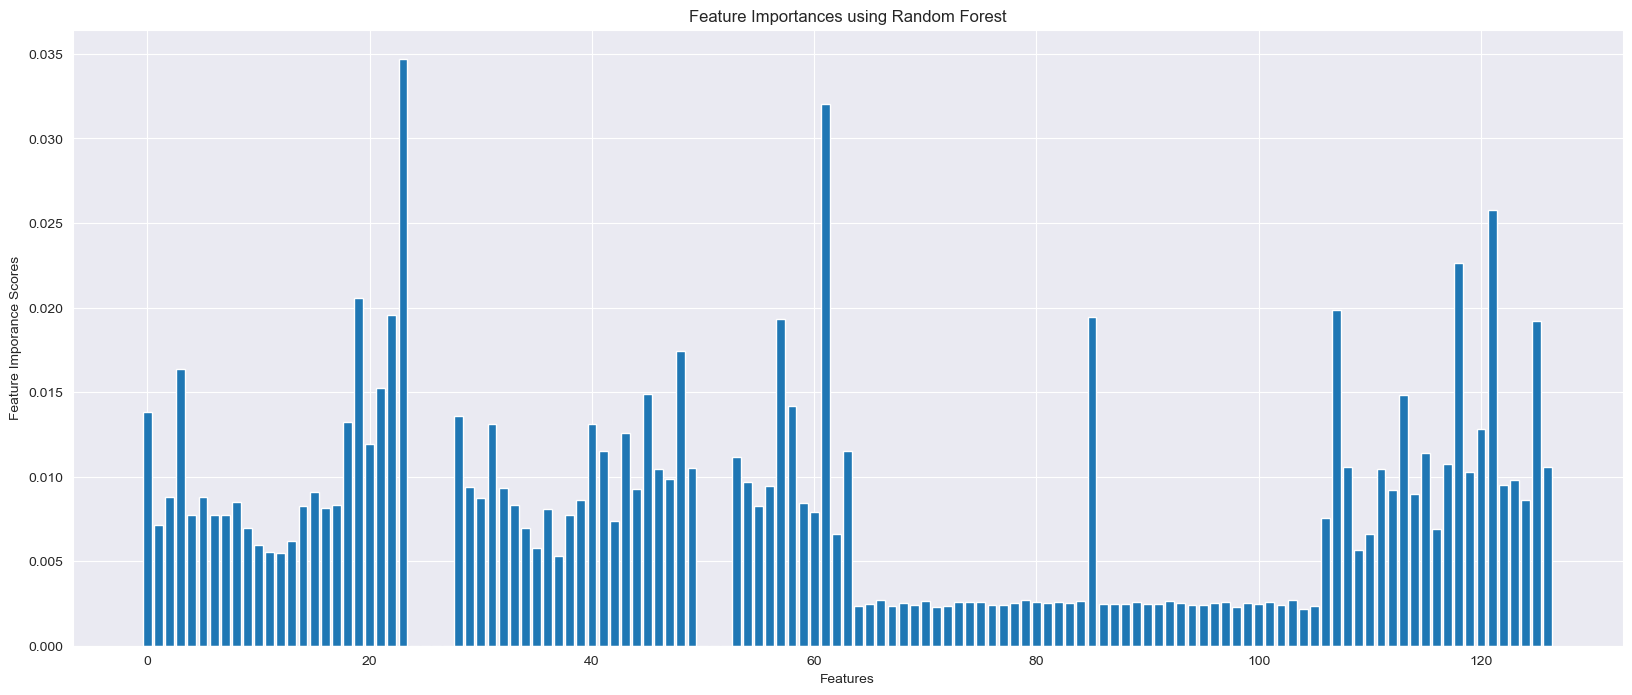

In [186]:
plt.figure(figsize = (20,8))

plt.bar(range(X.shape[1]), clf.feature_importances_)
plt.xticks()
plt.ylabel('Feature Imporance Scores')
plt.xlabel('Features')
plt.title('Feature Importances using Random Forest')
plt.show()

In [21]:

X_selected = pd.DataFrame(X_new).reset_index(drop=True)
y_selected = pd.Series(y_clipped).reset_index(drop=True)
data_selected = pd.concat([y_selected, X_selected], axis=1)
data_selected.to_csv("Torgo_selected.csv", index=False)
data_selected.isna().sum().sum()


0